# Bulldozer Price Prediction Project

## Project Overview
The goal of this project is to predict the sale price of bulldozers using structured historical auction data.  
This is a supervised machine learning regression problem where the target variable is `SalePrice`.

## Project Cycle
1. Problem Understanding
2. Data Loading
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building
7. Model Evaluation
8. Model Improvement
9. Final Training
10. Submission / Deployment Preparation

## Project Goal
Build a strong predictive model that can estimate bulldozer sale prices accurately and robustly.

## Main Target
- **Target Column:** `SalePrice`

## Problem Type
- **Type:** Regression

# Import All libraries

In [1]:
# IMPORT LIBRARIES
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Import Dataset

In [2]:
# DATASET PATHS
train_validation_path = r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\bulldozzer-project\data\bluebook-for-bulldozers\TrainAndValid.csv"
test_path = r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\bulldozzer-project\data\bluebook-for-bulldozers\Test.csv"

In [3]:
# LOAD DATASETS
train_validation = pd.read_csv(
    train_validation_path,
    low_memory=False,
    parse_dates=["saledate"]
)

test = pd.read_csv(
    test_path,
    low_memory=False,
    parse_dates=["saledate"]
)

print("Train_Validation Shape:", train_validation.shape)
print("Test Shape:", test.shape)

Train_Validation Shape: (412698, 53)
Test Shape: (12457, 52)


In [4]:
# QUICK PREVIEW
display(train_validation.head())
display(test.head())

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0000,999089,3157,121,3.0000,2004,68.0000,Low,2006-11-16,521D,521,D,NaN,NaN,NaN,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0000,117657,77,121,3.0000,1996,4640.0000,Low,2004-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0000,434808,7009,121,3.0000,2001,2838.0000,High,2004-02-26,226,226,NaN,NaN,NaN,NaN,Skid Steer Loader - 1351.0 to 1601.0 Lb Operat...,New York,SSL,Skid Steer Loaders,NaN,OROPS,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,None or Unspecified,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500.0000,1026470,332,121,3.0000,2001,3486.0000,High,2011-05-19,PC120-6E,PC120,NaN,-6E,NaN,Small,"Hydraulic Excavator, Track - 12.0 to 14.0 Metr...",Texas,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000.0000,1057373,17311,121,3.0000,2007,722.0000,Medium,2009-07-23,S175,S175,NaN,NaN,NaN,NaN,Skid Steer Loader - 1601.0 to 1751.0 Lb Operat...,New York,SSL,Skid Steer Loaders,NaN,EROPS,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,None or Unspecified,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0000,Low,2012-05-03,580G,580,G,NaN,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digg...,Wyoming,BL,Backhoe Loaders,Two Wheel Drive,OROPS,Yes,None or Unspecified,No,Standard,Standard,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0000,High,2012-05-10,936,936,NaN,NaN,NaN,Medium,Wheel Loader - 135.0 to 150.0 Horsepower,Virginia,WL,Wheel Loader,NaN,EROPS,Yes,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,20.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0000,Medium,2012-05-10,EC210BLC,EC210,B,NaN,LC,Large / Medium,"Hydraulic Excavator, Track - 21.0 to 24.0 Metr...",New Jersey,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,Steel,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0000,High,2012-05-10,330CL,330,C,NaN,L,Large / Medium,"Hydraulic Excavator, Track - 33.0 to 40.0 Metr...",New Jersey,TEX,Track Excavators,NaN,EROPS w AC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,NaN,NaN,NaN,NaN,NaN,None or Unspecified,NaN,NaN,NaN,Steel,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0000,Low,2012-05-10,650K,650,K,NaN,NaN,NaN,"Track Type Tractor, Dozer - 20.0 to 75.0 Horse...",Florida,TTT,Track Type Tractors,NaN,OROPS,NaN,NaN,NaN,NaN,Hydrostatic,NaN,NaN,NaN,NaN,NaN,2 Valve,NaN,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


# 1. Univariate Analysis

Univariate analysis focuses on understanding each feature individually.  
At this stage, we first identify feature groups such as numerical, categorical, and datetime columns.

This step helps us:
- understand the raw structure of the dataset
- prepare separate analysis paths for each feature type
- build reusable summary reports for later feature engineering

In [5]:
# =========================================================
# HELPER FUNCTIONS: FEATURE TYPE IDENTIFICATION
# =========================================================
import pandas as pd
import numpy as np


def find_feature_groups(df: pd.DataFrame, target_col: str = None) -> dict:
    """
    Identify numerical, categorical, datetime, boolean, and other feature groups.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, optional
        Target column to exclude from feature grouping.

    Returns
    -------
    dict
        Dictionary containing grouped feature lists.
    """
    data = df.copy()

    if target_col is not None and target_col in data.columns:
        data = data.drop(columns=[target_col])

    numerical_features = data.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = data.select_dtypes(include=["object", "category"]).columns.tolist()
    datetime_features = data.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    boolean_features = data.select_dtypes(include=["bool"]).columns.tolist()

    assigned = set(numerical_features + categorical_features + datetime_features + boolean_features)
    other_features = [col for col in data.columns if col not in assigned]

    return {
        "numerical_features": numerical_features,
        "categorical_features": categorical_features,
        "datetime_features": datetime_features,
        "boolean_features": boolean_features,
        "other_features": other_features
    }


def create_feature_type_summary_df(df: pd.DataFrame, target_col: str = None) -> pd.DataFrame:
    """
    Create a dataframe summarizing feature names, dtypes, and primary feature types.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    target_col : str, optional
        Target column to exclude.

    Returns
    -------
    pd.DataFrame
        Summary dataframe with feature identity information.
    """
    feature_groups = find_feature_groups(df=df, target_col=target_col)

    records = []

    for feature in feature_groups["numerical_features"]:
        records.append({
            "Feature_Name": feature,
            "Dtype": str(df[feature].dtype),
            "Primary_Feature_Type": "Numerical"
        })

    for feature in feature_groups["categorical_features"]:
        records.append({
            "Feature_Name": feature,
            "Dtype": str(df[feature].dtype),
            "Primary_Feature_Type": "Categorical"
        })

    for feature in feature_groups["datetime_features"]:
        records.append({
            "Feature_Name": feature,
            "Dtype": str(df[feature].dtype),
            "Primary_Feature_Type": "Datetime"
        })

    for feature in feature_groups["boolean_features"]:
        records.append({
            "Feature_Name": feature,
            "Dtype": str(df[feature].dtype),
            "Primary_Feature_Type": "Boolean"
        })

    for feature in feature_groups["other_features"]:
        records.append({
            "Feature_Name": feature,
            "Dtype": str(df[feature].dtype),
            "Primary_Feature_Type": "Other"
        })

    summary_df = pd.DataFrame(records).sort_values("Feature_Name").reset_index(drop=True)
    return summary_df

In [6]:
# =========================================================
# FEATURE GROUP IDENTIFICATION
# =========================================================
TARGET_COL = "SalePrice"

feature_groups = find_feature_groups(df=train_validation, target_col=TARGET_COL)

numerical_features = feature_groups["numerical_features"]
categorical_features = feature_groups["categorical_features"]
datetime_features = feature_groups["datetime_features"]
boolean_features = feature_groups["boolean_features"]
other_features = feature_groups["other_features"]

feature_type_summary_df = create_feature_type_summary_df(
    df=train_validation,
    target_col=TARGET_COL
)

print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))
print("Datetime Features:", len(datetime_features))
print("Boolean Features:", len(boolean_features))
print("Other Features:", len(other_features))

display(feature_type_summary_df.head(20))

Numerical Features: 7
Categorical Features: 44
Datetime Features: 1
Boolean Features: 0
Other Features: 0


,Feature_Name,Dtype,Primary_Feature_Type
0,Backhoe_Mounting,object,Categorical
1,Blade_Extension,object,Categorical
2,Blade_Type,object,Categorical
3,Blade_Width,object,Categorical
4,Coupler,object,Categorical
5,Coupler_System,object,Categorical
6,Differential_Type,object,Categorical
7,Drive_System,object,Categorical
8,Enclosure,object,Categorical
9,Enclosure_Type,object,Categorical


## 1.1 Numerical Features

In this section, we will analyze only numerical features.  
We start with feature identity so that each numerical column is clearly defined before deeper profiling.

## 1.1.1 Feature Identity

Feature identity is the first step of numerical univariate analysis.  
It helps us confirm which columns are numerical, how they are stored, and whether they are truly numerical or may need further review later.

In [7]:
# =========================================================
# HELPER FUNCTION: NUMERICAL FEATURE IDENTITY
# =========================================================
def create_numerical_feature_identity_df(
    feature_type_summary_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Filter the full feature type summary and keep only numerical feature identity info.

    Parameters
    ----------
    feature_type_summary_df : pd.DataFrame
        Dataframe created from create_feature_type_summary_df().

    Returns
    -------
    pd.DataFrame
        Numerical feature identity dataframe.
    """
    numerical_feature_identity_df = feature_type_summary_df[
        feature_type_summary_df["Primary_Feature_Type"] == "Numerical"
    ].copy().reset_index(drop=True)

    return numerical_feature_identity_df

In [8]:
# =========================================================
# NUMERICAL FEATURE IDENTITY DATAFRAME
# =========================================================
numerical_feature_identity_df = create_numerical_feature_identity_df(
    feature_type_summary_df=feature_type_summary_df
)

print("Numerical Feature Count:", numerical_feature_identity_df.shape[0])
display(numerical_feature_identity_df.head(20))

Numerical Feature Count: 7


,Feature_Name,Dtype,Primary_Feature_Type
0,MachineHoursCurrentMeter,float64,Numerical
1,MachineID,int64,Numerical
2,ModelID,int64,Numerical
3,SalesID,int64,Numerical
4,YearMade,int64,Numerical
5,auctioneerID,float64,Numerical
6,datasource,int64,Numerical


In [9]:
# OPTIONAL QUICK LISTS
print("Numerical Features List:")
print(numerical_features)

print("\nCategorical Features List:")
print(categorical_features)

print("\nDatetime Features List:")
print(datetime_features)

Numerical Features List:
['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter']

Categorical Features List:
['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls']

Datetime Features List:
['saledate']


## 1.1.2 Missing Value Summary

This section helps us understand the missing-value burden of each numerical feature.

- **Missing_Count**: Total number of missing values in the feature
- **Missing_Percentage**: Percentage of missing values in the feature
- **Non_Null_Count**: Total number of non-missing usable values

In [10]:
# =========================================================
# HELPER FUNCTION: NUMERICAL MISSING VALUE SUMMARY
# =========================================================
def create_numerical_missing_summary_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a missing value summary dataframe for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    numerical_features : list
        List of numerical feature names.

    Returns
    -------
    pd.DataFrame
        Numerical missing value summary dataframe.
    """
    records = []

    total_rows = df.shape[0]

    for feature in numerical_features:
        missing_count = df[feature].isna().sum()
        non_null_count = df[feature].notna().sum()
        missing_percentage = (missing_count / total_rows) * 100 if total_rows > 0 else 0

        records.append({
            "Feature_Name": feature,
            "Missing_Count": missing_count,
            "Missing_Percentage": missing_percentage,
            "Non_Null_Count": non_null_count
        })

    numerical_missing_summary_df = pd.DataFrame(records).sort_values(
        by=["Missing_Percentage", "Missing_Count"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return numerical_missing_summary_df

In [11]:
# =========================================================
# NUMERICAL MISSING VALUE SUMMARY DATAFRAME
# =========================================================
numerical_missing_summary_df = create_numerical_missing_summary_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Missing Summary Shape:", numerical_missing_summary_df.shape)
display(numerical_missing_summary_df.head(20))

Numerical Missing Summary Shape: (7, 4)


,Feature_Name,Missing_Count,Missing_Percentage,Non_Null_Count
0,MachineHoursCurrentMeter,265194,64.2586,147504
1,auctioneerID,20136,4.8791,392562
2,SalesID,0,0.0000,412698
3,MachineID,0,0.0000,412698
4,ModelID,0,0.0000,412698
5,datasource,0,0.0000,412698
6,YearMade,0,0.0000,412698


### Missing Value Visualization

This chart highlights the numerical features with the highest missing-value burden.  
It helps us quickly identify which features may need stronger missing-value handling.

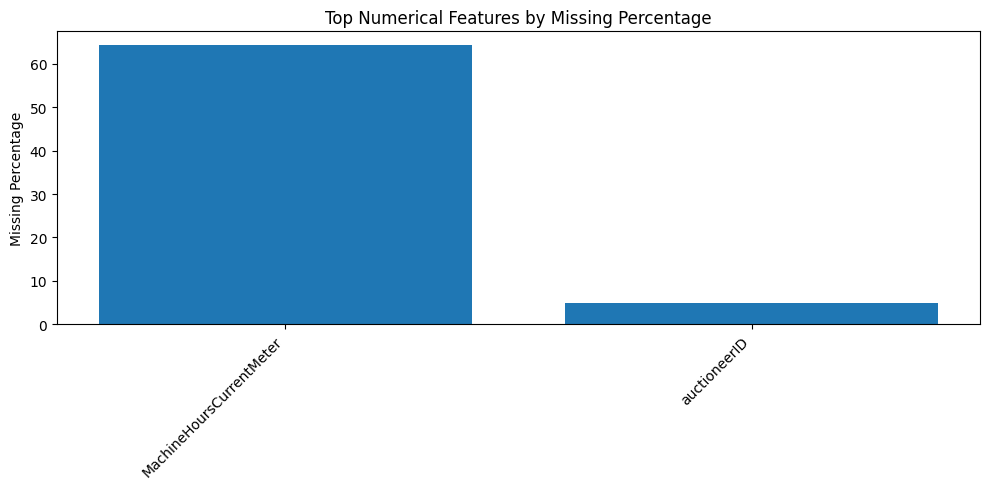

In [12]:
# Missing value bar chart

plot_df = numerical_missing_summary_df[
    numerical_missing_summary_df["Missing_Count"] > 0
].sort_values("Missing_Percentage", ascending=False).head(10)

if not plot_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["Feature_Name"], plot_df["Missing_Percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Missing Percentage")
    plt.title("Top Numerical Features by Missing Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in numerical features.")

## 1.1.3 Uniqueness and Feature Nature

This section helps us understand whether a numerical feature behaves like a continuous variable or more like a coded categorical variable.

- **Unique_Count**: Total number of unique values in the feature
- **Unique_Ratio**: Ratio of unique values compared to total rows
- **Looks_Like_Categorical_Flag**: Indicates whether a numerical feature may actually behave like a categorical feature

In [13]:
# Helper function: numerical uniqueness and feature nature

def create_numerical_uniqueness_summary_df(
    df: pd.DataFrame,
    numerical_features: list,
    low_cardinality_threshold: int = 15,
    low_ratio_threshold: float = 0.01
) -> pd.DataFrame:
    """
    Create a uniqueness summary dataframe for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    numerical_features : list
        List of numerical feature names.
    low_cardinality_threshold : int, optional
        Maximum unique count threshold to flag a numeric feature as possibly categorical.
    low_ratio_threshold : float, optional
        Maximum unique ratio threshold to flag a numeric feature as possibly categorical.

    Returns
    -------
    pd.DataFrame
        Numerical uniqueness summary dataframe.
    """
    records = []
    total_rows = df.shape[0]

    for feature in numerical_features:
        unique_count = df[feature].nunique(dropna=True)
        unique_ratio = unique_count / total_rows if total_rows > 0 else 0

        looks_like_categorical = (
            unique_count <= low_cardinality_threshold
            or unique_ratio <= low_ratio_threshold
        )

        records.append({
            "Feature_Name": feature,
            "Unique_Count": unique_count,
            "Unique_Ratio": unique_ratio,
            "Looks_Like_Categorical_Flag": looks_like_categorical
        })

    numerical_uniqueness_summary_df = pd.DataFrame(records).sort_values(
        by=["Looks_Like_Categorical_Flag", "Unique_Count", "Unique_Ratio"],
        ascending=[False, True, True]
    ).reset_index(drop=True)

    return numerical_uniqueness_summary_df

In [14]:
# Numerical uniqueness summary dataframe

numerical_uniqueness_summary_df = create_numerical_uniqueness_summary_df(
    df=train_validation,
    numerical_features=numerical_features,
    low_cardinality_threshold=15,
    low_ratio_threshold=0.01
)

print("Numerical Uniqueness Summary Shape:", numerical_uniqueness_summary_df.shape)
display(numerical_uniqueness_summary_df.head(20))

Numerical Uniqueness Summary Shape: (7, 4)


,Feature_Name,Unique_Count,Unique_Ratio,Looks_Like_Categorical_Flag
0,datasource,6,0.0000,True
1,auctioneerID,30,0.0001,True
2,YearMade,73,0.0002,True
3,ModelID,5281,0.0128,False
4,MachineHoursCurrentMeter,15633,0.0379,False
5,MachineID,348808,0.8452,False
6,SalesID,412698,1.0000,False


### Uniqueness Visualization

This chart shows numerical features with the lowest unique counts.  
It helps us identify features that may behave more like coded categorical variables than continuous numerical variables.

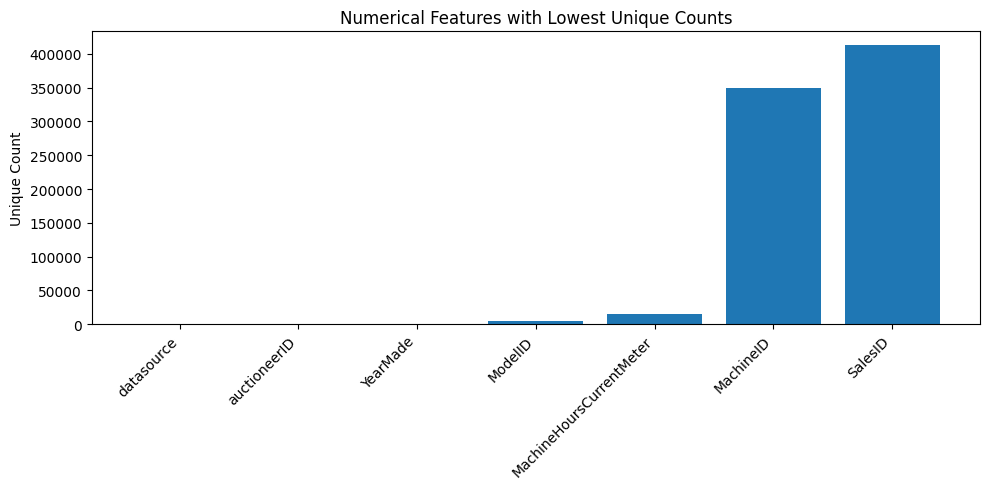

In [15]:
# Unique count bar chart

plot_df = numerical_uniqueness_summary_df.sort_values("Unique_Count", ascending=True).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Feature_Name"], plot_df["Unique_Count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Unique Count")
plt.title("Numerical Features with Lowest Unique Counts")
plt.tight_layout()
plt.show()

## 1.1.4 Central Tendency

This section helps us understand the central location of each numerical feature.

- **Mean**: Average value of the feature
- **Median**: Middle value of the feature
- **Mode**: Most frequent value of the feature

In [16]:
# Helper function: numerical central tendency

def create_numerical_central_tendency_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a central tendency summary dataframe for numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    numerical_features : list
        List of numerical feature names.

    Returns
    -------
    pd.DataFrame
        Numerical central tendency summary dataframe.
    """
    records = []

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce")

        mean_value = series.mean()
        median_value = series.median()

        mode_series = series.mode(dropna=True)
        mode_value = mode_series.iloc[0] if not mode_series.empty else np.nan

        records.append({
            "Feature_Name": feature,
            "Mean": mean_value,
            "Median": median_value,
            "Mode": mode_value
        })

    numerical_central_tendency_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_central_tendency_df

In [17]:
# Numerical central tendency dataframe

numerical_central_tendency_df = create_numerical_central_tendency_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Central Tendency Shape:", numerical_central_tendency_df.shape)
display(numerical_central_tendency_df.head(20))

Numerical Central Tendency Shape: (7, 4)


,Feature_Name,Mean,Median,Mode
0,SalesID,2011161.1636,1645852.5000,1139246.0000
1,MachineID,1230061.4366,1284397.0000,2283592.0000
2,ModelID,6947.2018,4605.0000,4605.0000
3,datasource,135.1694,132.0000,132.0000
4,auctioneerID,6.5853,2.0000,1.0000
5,YearMade,1899.0496,1995.0000,1000.0000
6,MachineHoursCurrentMeter,3522.9883,0.0000,0.0000


In [18]:
# Optional quick check: compare mean and median

numerical_central_tendency_df.assign(
    Mean_Median_Difference=numerical_central_tendency_df["Mean"] - numerical_central_tendency_df["Median"]
).head(20)

,Feature_Name,Mean,Median,Mode,Mean_Median_Difference
0,SalesID,2011161.1636,1645852.5000,1139246.0000,365308.6636
1,MachineID,1230061.4366,1284397.0000,2283592.0000,-54335.5634
2,ModelID,6947.2018,4605.0000,4605.0000,2342.2018
3,datasource,135.1694,132.0000,132.0000,3.1694
4,auctioneerID,6.5853,2.0000,1.0000,4.5853
5,YearMade,1899.0496,1995.0000,1000.0000,-95.9504
6,MachineHoursCurrentMeter,3522.9883,0.0000,0.0000,3522.9883


### Central Tendency Visualization

This chart compares numerical features based on the difference between mean and median.  
A large difference may indicate skewness or an imbalanced distribution.

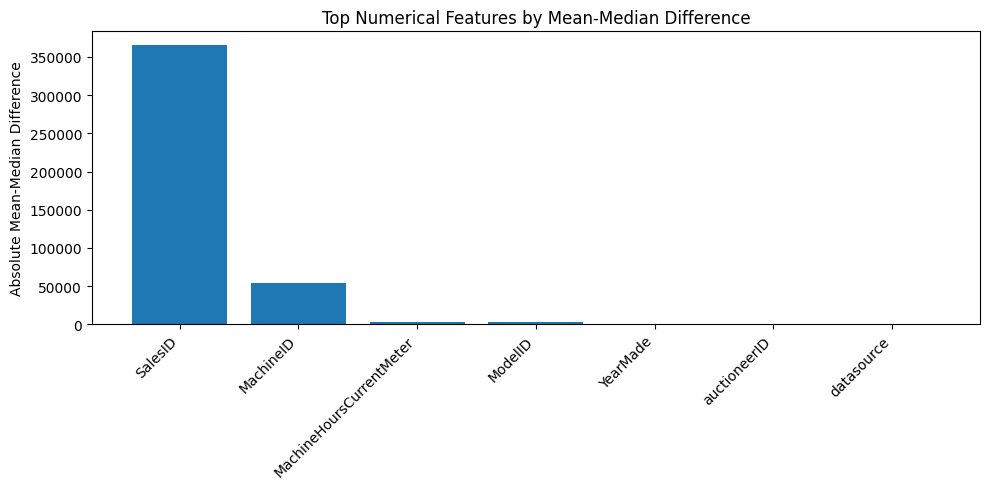

In [19]:
# Mean-median difference chart

plot_df = numerical_central_tendency_df.copy()
plot_df["Mean_Median_Difference"] = (plot_df["Mean"] - plot_df["Median"]).abs()
plot_df = plot_df.sort_values("Mean_Median_Difference", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Feature_Name"], plot_df["Mean_Median_Difference"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Absolute Mean-Median Difference")
plt.title("Top Numerical Features by Mean-Median Difference")
plt.tight_layout()
plt.show()

### Mean vs Median Comparison

This chart directly compares the mean and median values of selected numerical features.  
It helps visually detect imbalance and potential skewness in the distribution.

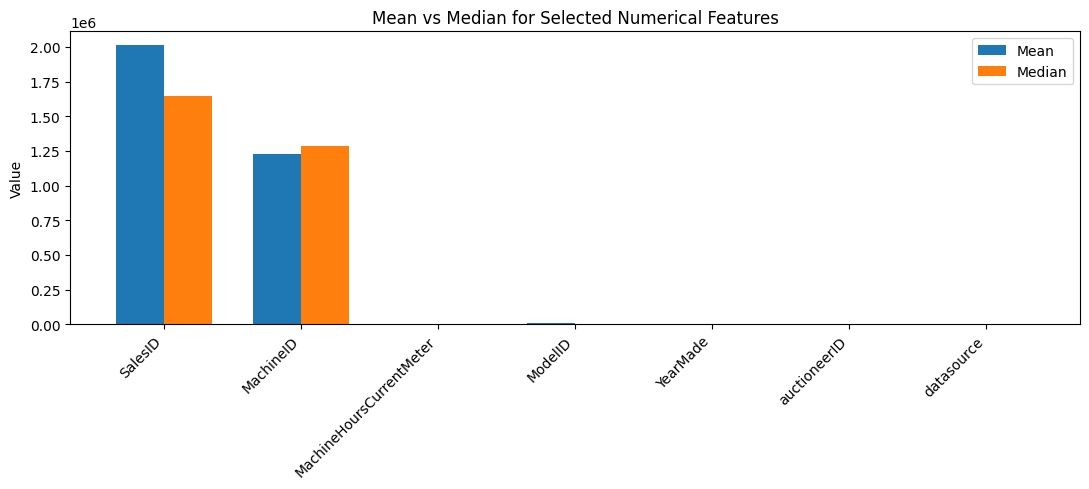

In [20]:
# Mean vs median comparison chart

plot_df = numerical_central_tendency_df.copy()
plot_df["Mean_Median_Difference"] = (plot_df["Mean"] - plot_df["Median"]).abs()
plot_df = plot_df.sort_values("Mean_Median_Difference", ascending=False).head(8)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, plot_df["Mean"], width=width, label="Mean")
plt.bar(x + width / 2, plot_df["Median"], width=width, label="Median")

plt.xticks(x, plot_df["Feature_Name"], rotation=45, ha="right")
plt.ylabel("Value")
plt.title("Mean vs Median for Selected Numerical Features")
plt.legend()
plt.tight_layout()
plt.show()

## 1.1.5 Dispersion / Spread

This section helps us understand how widely each numerical feature is spread.

- **Std**: Standard deviation of the feature
- **Min**: Minimum value of the feature
- **Max**: Maximum value of the feature
- **Range**: Difference between maximum and minimum
- **Q1 (25%)**: First quartile
- **Q3 (75%)**: Third quartile
- **IQR**: Interquartile range

In [21]:
# Helper function: numerical dispersion / spread summary

def create_numerical_dispersion_summary_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a dispersion / spread summary dataframe for numerical features.
    """
    records = []

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce")

        min_value = series.min()
        max_value = series.max()
        q1_value = series.quantile(0.25)
        q3_value = series.quantile(0.75)
        iqr_value = q3_value - q1_value
        range_value = max_value - min_value

        records.append({
            "Feature_Name": feature,
            "Std": series.std(),
            "Min": min_value,
            "Max": max_value,
            "Range": range_value,
            "Q1 (25%)": q1_value,
            "Q3 (75%)": q3_value,
            "IQR": iqr_value
        })

    numerical_dispersion_summary_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_dispersion_summary_df

In [22]:
# Numerical dispersion / spread dataframe

numerical_dispersion_summary_df = create_numerical_dispersion_summary_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Dispersion Summary Shape:", numerical_dispersion_summary_df.shape)
display(numerical_dispersion_summary_df.head(20))

Numerical Dispersion Summary Shape: (7, 8)


,Feature_Name,Std,Min,Max,Range,Q1 (25%),Q3 (75%),IQR
0,SalesID,1080067.7245,1139246.0000,6333349.0000,5194103.0000,1421897.7500,2261012.5000,839114.7500
1,MachineID,453953.2579,0.0000,2486330.0000,2486330.0000,1088593.2500,1478079.2500,389486.0000
2,ModelID,6280.8250,28.0000,37198.0000,37170.0000,3261.0000,8899.0000,5638.0000
3,datasource,9.6467,121.0000,173.0000,52.0000,132.0000,136.0000,4.0000
4,auctioneerID,17.1584,0.0000,99.0000,99.0000,1.0000,4.0000,3.0000
5,YearMade,292.1902,1000.0000,2014.0000,1014.0000,1985.0000,2001.0000,16.0000
6,MachineHoursCurrentMeter,27169.9287,0.0000,2483300.0000,2483300.0000,0.0000,3209.0000,3209.0000


### Dispersion Visualization

The following plots focus on the numerical features with the highest spread.  
Instead of only using summary bars, we use distribution-based plots so that the spread can be seen more directly.

In [23]:
# Helper function: select top spread features

def get_top_spread_features(
    dispersion_df: pd.DataFrame,
    rank_by: str = "IQR",
    top_n: int = 8
) -> list:
    """
    Select top numerical features based on a spread metric.
    """
    top_features = (
        dispersion_df
        .sort_values(rank_by, ascending=False)
        .head(top_n)["Feature_Name"]
        .tolist()
    )
    return top_features

In [24]:
# Helper function: boxplot for top spread numerical features

def plot_top_spread_boxplot(
    df: pd.DataFrame,
    feature_list: list,
    figure_size: tuple = (12, 6)
) -> None:
    """
    Plot horizontal boxplots for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for boxplot.")
        return

    plot_df = df[feature_list].copy()
    plot_df = plot_df.melt(var_name="Feature_Name", value_name="Value").dropna()

    plt.figure(figsize=figure_size)
    sns.boxplot(data=plot_df, x="Value", y="Feature_Name")
    plt.title("Boxplot of Top Numerical Features by Spread")
    plt.xlabel("Value")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

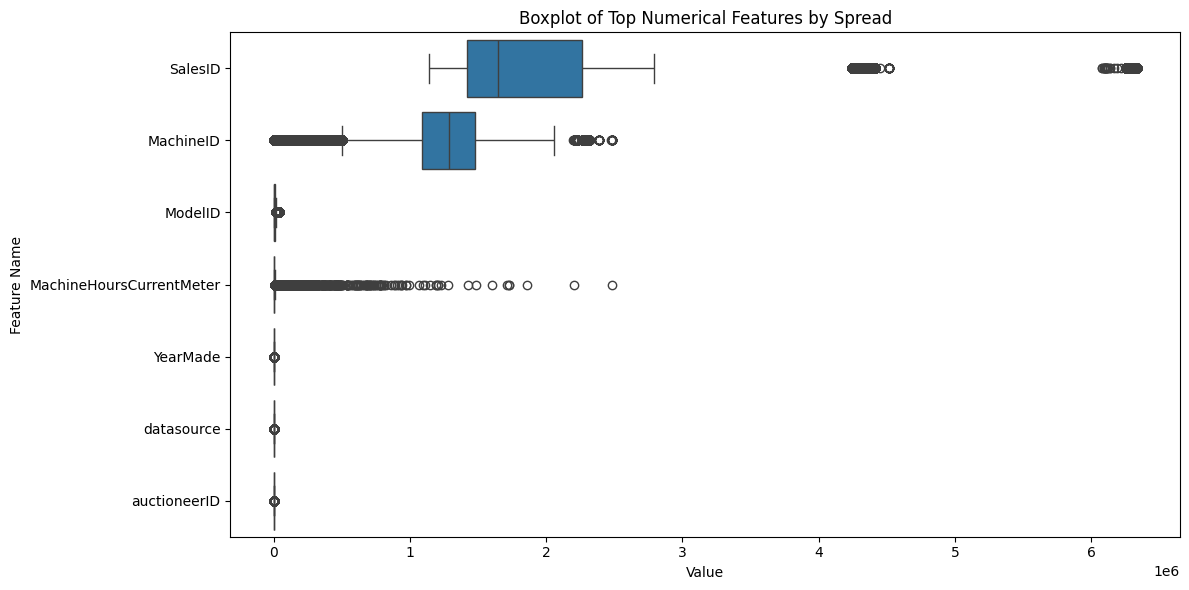

In [25]:
# Boxplot for top spread features

top_spread_features = get_top_spread_features(
    dispersion_df=numerical_dispersion_summary_df,
    rank_by="IQR",
    top_n=8
)

plot_top_spread_boxplot(
    df=train_validation,
    feature_list=top_spread_features,
    figure_size=(12, 6)
)

### Violin Plot Visualization

This plot complements the boxplot by showing the density and shape of the distribution for the same high-spread numerical features.

In [26]:
# Helper function: violin plot for top spread numerical features

def plot_top_spread_violinplot(
    df: pd.DataFrame,
    feature_list: list,
    figure_size: tuple = (12, 6)
) -> None:
    """
    Plot horizontal violin plots for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for violin plot.")
        return

    plot_df = df[feature_list].copy()
    plot_df = plot_df.melt(var_name="Feature_Name", value_name="Value").dropna()

    plt.figure(figsize=figure_size)
    sns.violinplot(data=plot_df, x="Value", y="Feature_Name", cut=0)
    plt.title("Violin Plot of Top Numerical Features by Spread")
    plt.xlabel("Value")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

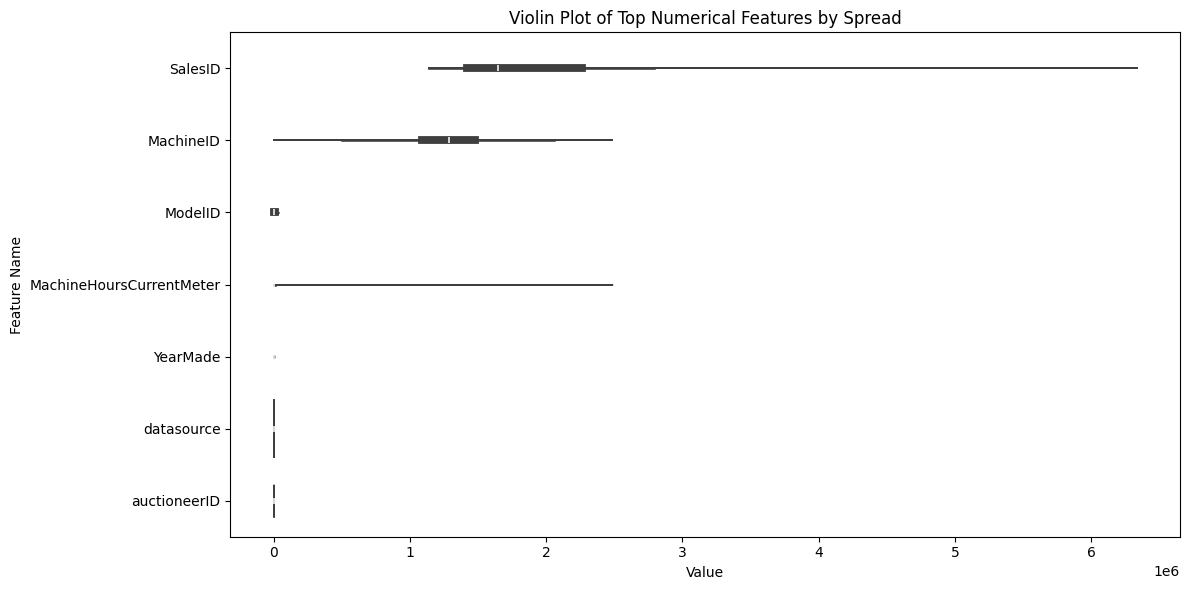

In [27]:
# Violin plot for top spread features

plot_top_spread_violinplot(
    df=train_validation,
    feature_list=top_spread_features,
    figure_size=(12, 6)
)

## 1.1.6 Percentile Summary

This section helps us understand the lower and upper tails of each numerical feature.

- **P01**: 1st percentile, showing the extreme lower tail
- **P05**: 5th percentile, showing the lower tail
- **P95**: 95th percentile, showing the upper tail
- **P99**: 99th percentile, showing the extreme upper tail

In [28]:
# Helper function: numerical percentile summary

def create_numerical_percentile_summary_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a percentile summary dataframe for numerical features.
    """
    records = []

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce")

        p01 = series.quantile(0.01)
        p05 = series.quantile(0.05)
        p95 = series.quantile(0.95)
        p99 = series.quantile(0.99)

        records.append({
            "Feature_Name": feature,
            "P01": p01,
            "P05": p05,
            "P95": p95,
            "P99": p99
        })

    numerical_percentile_summary_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_percentile_summary_df

In [29]:
# Numerical percentile summary dataframe

numerical_percentile_summary_df = create_numerical_percentile_summary_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Percentile Summary Shape:", numerical_percentile_summary_df.shape)
display(numerical_percentile_summary_df.head(20))

Numerical Percentile Summary Shape: (7, 5)


,Feature_Name,P01,P05,P95,P99
0,SalesID,1153079.8200,1210925.8500,4357166.8000,6302738.0300
1,MachineID,30877.9100,217982.8500,1864816.3500,2296523.0000
2,ModelID,108.0000,590.0000,22114.0000,28439.0000
3,datasource,121.0000,121.0000,149.0000,172.0000
4,auctioneerID,1.0000,1.0000,22.0000,99.0000
5,YearMade,1000.0000,1000.0000,2005.0000,2007.0000
6,MachineHoursCurrentMeter,0.0000,0.0000,10746.0000,22696.6100


### Percentile Interval Visualization

The following plot shows the percentile interval of selected numerical features.  
The long line represents the extreme interval from **P01 to P99**, and the marker points highlight the inner interval from **P05 to P95**.

In [30]:
# Helper function: select top numerical features by percentile spread

def get_top_percentile_spread_features(
    percentile_df: pd.DataFrame,
    rank_by: str = "P99_P01_Spread",
    top_n: int = 8
) -> list:
    """
    Select top numerical features based on percentile spread.
    """
    temp_df = percentile_df.copy()
    temp_df["P99_P01_Spread"] = temp_df["P99"] - temp_df["P01"]
    temp_df["P95_P05_Spread"] = temp_df["P95"] - temp_df["P05"]

    top_features = (
        temp_df
        .sort_values(rank_by, ascending=False)
        .head(top_n)["Feature_Name"]
        .tolist()
    )

    return top_features

In [31]:
# Helper function: percentile interval plot

def plot_percentile_interval(
    percentile_df: pd.DataFrame,
    feature_list: list,
    figure_size: tuple = (12, 6)
) -> None:
    """
    Plot percentile intervals for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for percentile interval plot.")
        return

    plot_df = percentile_df[
        percentile_df["Feature_Name"].isin(feature_list)
    ].copy()

    plot_df["P99_P01_Spread"] = plot_df["P99"] - plot_df["P01"]
    plot_df = plot_df.sort_values("P99_P01_Spread", ascending=True).reset_index(drop=True)

    y_positions = np.arange(len(plot_df))

    plt.figure(figsize=figure_size)

    # Outer interval: P01 to P99
    for i, row in plot_df.iterrows():
        plt.hlines(
            y=i,
            xmin=row["P01"],
            xmax=row["P99"],
            linewidth=3
        )

    # Inner points: P05 and P95
    plt.scatter(plot_df["P05"], y_positions, s=40, label="P05")
    plt.scatter(plot_df["P95"], y_positions, s=40, label="P95")

    plt.yticks(y_positions, plot_df["Feature_Name"])
    plt.xlabel("Value")
    plt.ylabel("Feature Name")
    plt.title("Percentile Interval Plot for Selected Numerical Features")
    plt.legend()
    plt.tight_layout()
    plt.show()

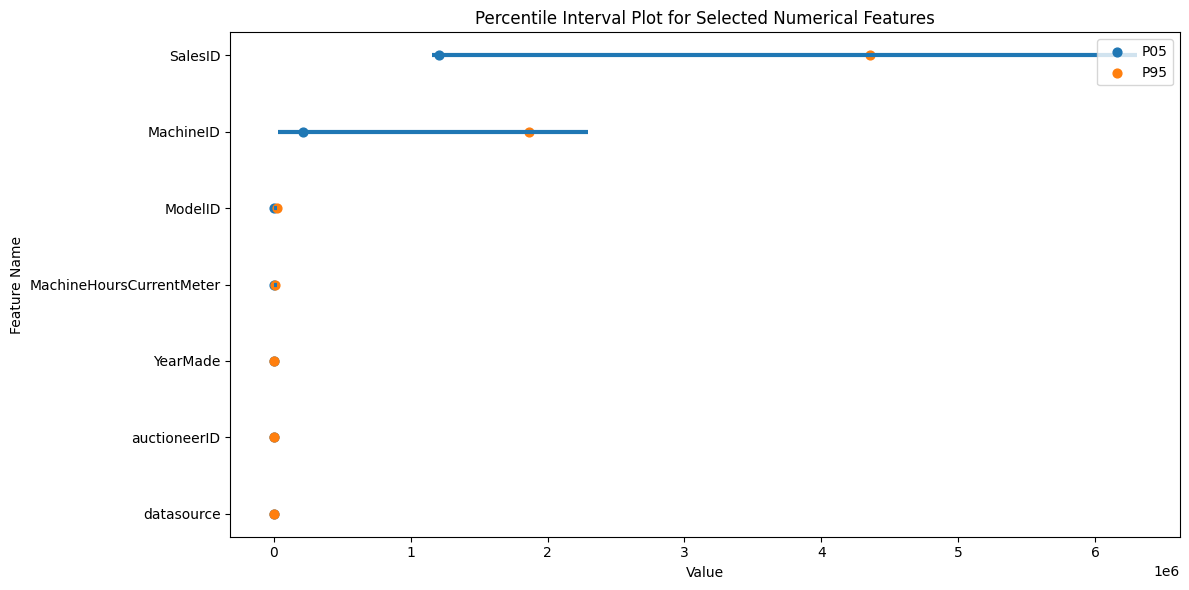

In [32]:
# Percentile interval plot for wide-tail features

top_percentile_features = get_top_percentile_spread_features(
    percentile_df=numerical_percentile_summary_df,
    rank_by="P99_P01_Spread",
    top_n=8
)

plot_percentile_interval(
    percentile_df=numerical_percentile_summary_df,
    feature_list=top_percentile_features,
    figure_size=(12, 6)
)

### Tail Spread Visualization

This plot compares the extreme percentile spread of selected numerical features using the range from **P01 to P99**.

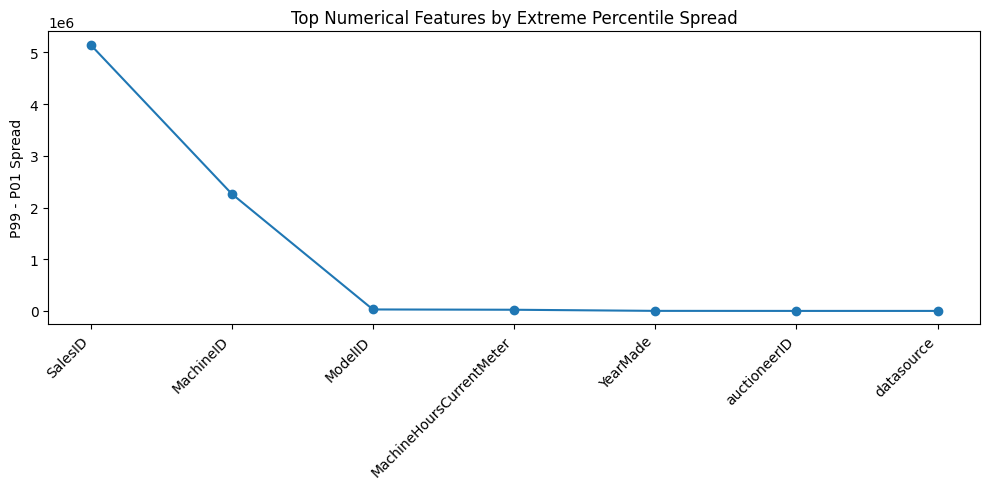

In [33]:
# Optional tail spread plot

plot_df = numerical_percentile_summary_df.copy()
plot_df["P99_P01_Spread"] = plot_df["P99"] - plot_df["P01"]
plot_df = plot_df.sort_values("P99_P01_Spread", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Feature_Name"], plot_df["P99_P01_Spread"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("P99 - P01 Spread")
plt.title("Top Numerical Features by Extreme Percentile Spread")
plt.tight_layout()
plt.show()

## 1.1.7 Distribution Shape

This section helps us understand the overall shape of each numerical feature distribution.

- **Skewness**: Measures asymmetry in the distribution
- **Skewness_Level**: Human-readable skewness category
- **Kurtosis**: Measures tail heaviness
- **Distribution_Shape**: General shape description such as symmetric, right-skewed, or left-skewed

In [34]:
# Helper function: numerical distribution shape summary

def create_numerical_distribution_shape_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a distribution shape summary dataframe for numerical features.
    """
    records = []

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce").dropna()

        skewness_value = series.skew()
        kurtosis_value = series.kurt()

        if pd.isna(skewness_value):
            skewness_level = "Unknown"
            distribution_shape = "Unknown"
        elif abs(skewness_value) < 0.5:
            skewness_level = "Approximately Symmetric"
            distribution_shape = "Symmetric"
        elif 0.5 <= skewness_value < 1:
            skewness_level = "Moderately Right-Skewed"
            distribution_shape = "Right-Skewed"
        elif skewness_value >= 1:
            skewness_level = "Highly Right-Skewed"
            distribution_shape = "Right-Skewed"
        elif -1 < skewness_value <= -0.5:
            skewness_level = "Moderately Left-Skewed"
            distribution_shape = "Left-Skewed"
        else:
            skewness_level = "Highly Left-Skewed"
            distribution_shape = "Left-Skewed"

        records.append({
            "Feature_Name": feature,
            "Skewness": skewness_value,
            "Skewness_Level": skewness_level,
            "Kurtosis": kurtosis_value,
            "Distribution_Shape": distribution_shape
        })

    numerical_distribution_shape_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_distribution_shape_df

In [35]:
# Numerical distribution shape dataframe

numerical_distribution_shape_df = create_numerical_distribution_shape_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Distribution Shape Summary Shape:", numerical_distribution_shape_df.shape)
display(numerical_distribution_shape_df.head(20))

Numerical Distribution Shape Summary Shape: (7, 5)


,Feature_Name,Skewness,Skewness_Level,Kurtosis,Distribution_Shape
0,SalesID,2.7208,Highly Right-Skewed,7.4134,Right-Skewed
1,MachineID,-0.6345,Moderately Left-Skewed,0.9091,Left-Skewed
2,ModelID,1.7467,Highly Right-Skewed,3.0409,Right-Skewed
3,datasource,2.4381,Highly Right-Skewed,6.8564,Right-Skewed
4,auctioneerID,4.8088,Highly Right-Skewed,22.8554,Right-Skewed
5,YearMade,-2.7486,Highly Left-Skewed,5.5661,Left-Skewed
6,MachineHoursCurrentMeter,37.1716,Highly Right-Skewed,1964.1945,Right-Skewed


### Distribution Visualization

The following plots focus on the most skewed numerical features.  
This helps us directly inspect whether the distributions are symmetric, right-skewed, or left-skewed.

In [36]:
# Helper function: select top skewed numerical features

def get_top_skewed_features(
    distribution_df: pd.DataFrame,
    top_n: int = 6
) -> list:
    """
    Select top numerical features based on absolute skewness.
    """
    temp_df = distribution_df.copy()
    temp_df["Abs_Skewness"] = temp_df["Skewness"].abs()

    top_features = (
        temp_df
        .sort_values("Abs_Skewness", ascending=False)
        .head(top_n)["Feature_Name"]
        .tolist()
    )

    return top_features

In [37]:
# Helper function: histogram grid for selected numerical features

def plot_numerical_histograms(
    df: pd.DataFrame,
    feature_list: list,
    bins: int = 30,
    cols: int = 2,
    figure_height_per_row: int = 4
) -> None:
    """
    Plot histograms for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for histogram plot.")
        return

    plot_df = df[feature_list].copy()
    n_features = len(feature_list)
    rows = int(np.ceil(n_features / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * figure_height_per_row))
    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, feature_list):
        series = pd.to_numeric(plot_df[feature], errors="coerce").dropna()
        ax.hist(series, bins=bins)
        ax.set_title(f"Histogram: {feature}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")

    for ax in axes[len(feature_list):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

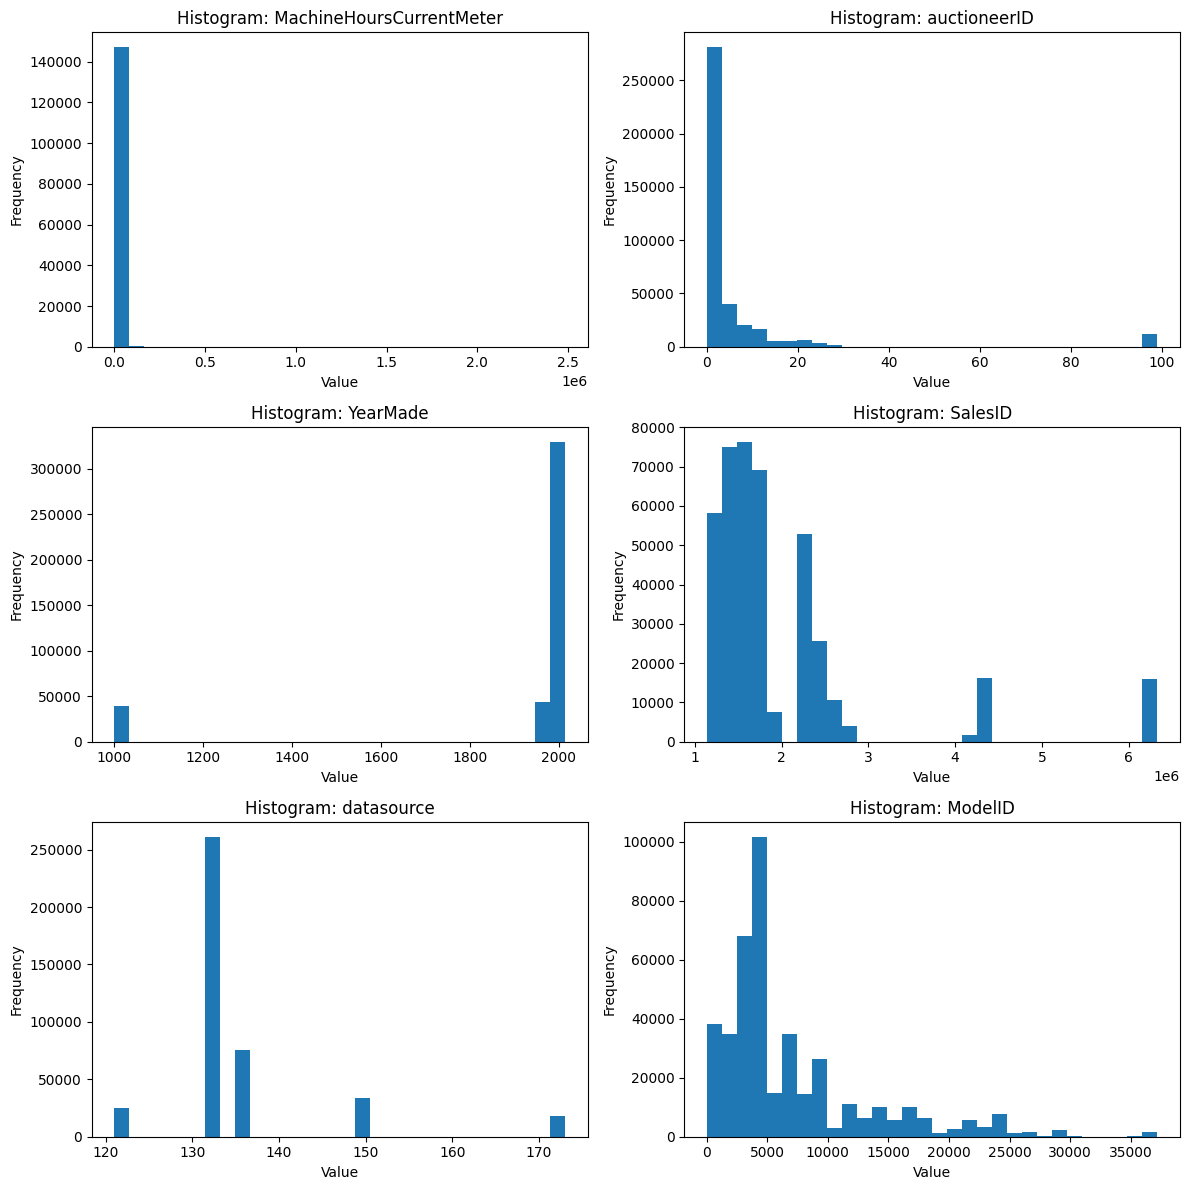

In [38]:
# Histogram plot for top skewed numerical features

top_skewed_features = get_top_skewed_features(
    distribution_df=numerical_distribution_shape_df,
    top_n=6
)

plot_numerical_histograms(
    df=train_validation,
    feature_list=top_skewed_features,
    bins=30,
    cols=2,
    figure_height_per_row=4
)

### KDE Visualization

This plot complements the histogram by showing the smoothed density curve of the same skewed numerical features.

In [39]:
# Helper function: KDE plot grid for selected numerical features

def plot_numerical_kde(
    df: pd.DataFrame,
    feature_list: list,
    cols: int = 2,
    figure_height_per_row: int = 4
) -> None:
    """
    Plot KDE curves for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for KDE plot.")
        return

    plot_df = df[feature_list].copy()
    n_features = len(feature_list)
    rows = int(np.ceil(n_features / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * figure_height_per_row))
    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, feature_list):
        series = pd.to_numeric(plot_df[feature], errors="coerce").dropna()

        if series.nunique() > 1:
            sns.kdeplot(x=series, ax=ax, fill=False)
            ax.set_title(f"KDE Plot: {feature}")
            ax.set_xlabel("Value")
            ax.set_ylabel("Density")
        else:
            ax.text(0.5, 0.5, "Not enough variation for KDE", ha="center", va="center")
            ax.set_title(f"KDE Plot: {feature}")
            ax.set_axis_off()

    for ax in axes[len(feature_list):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

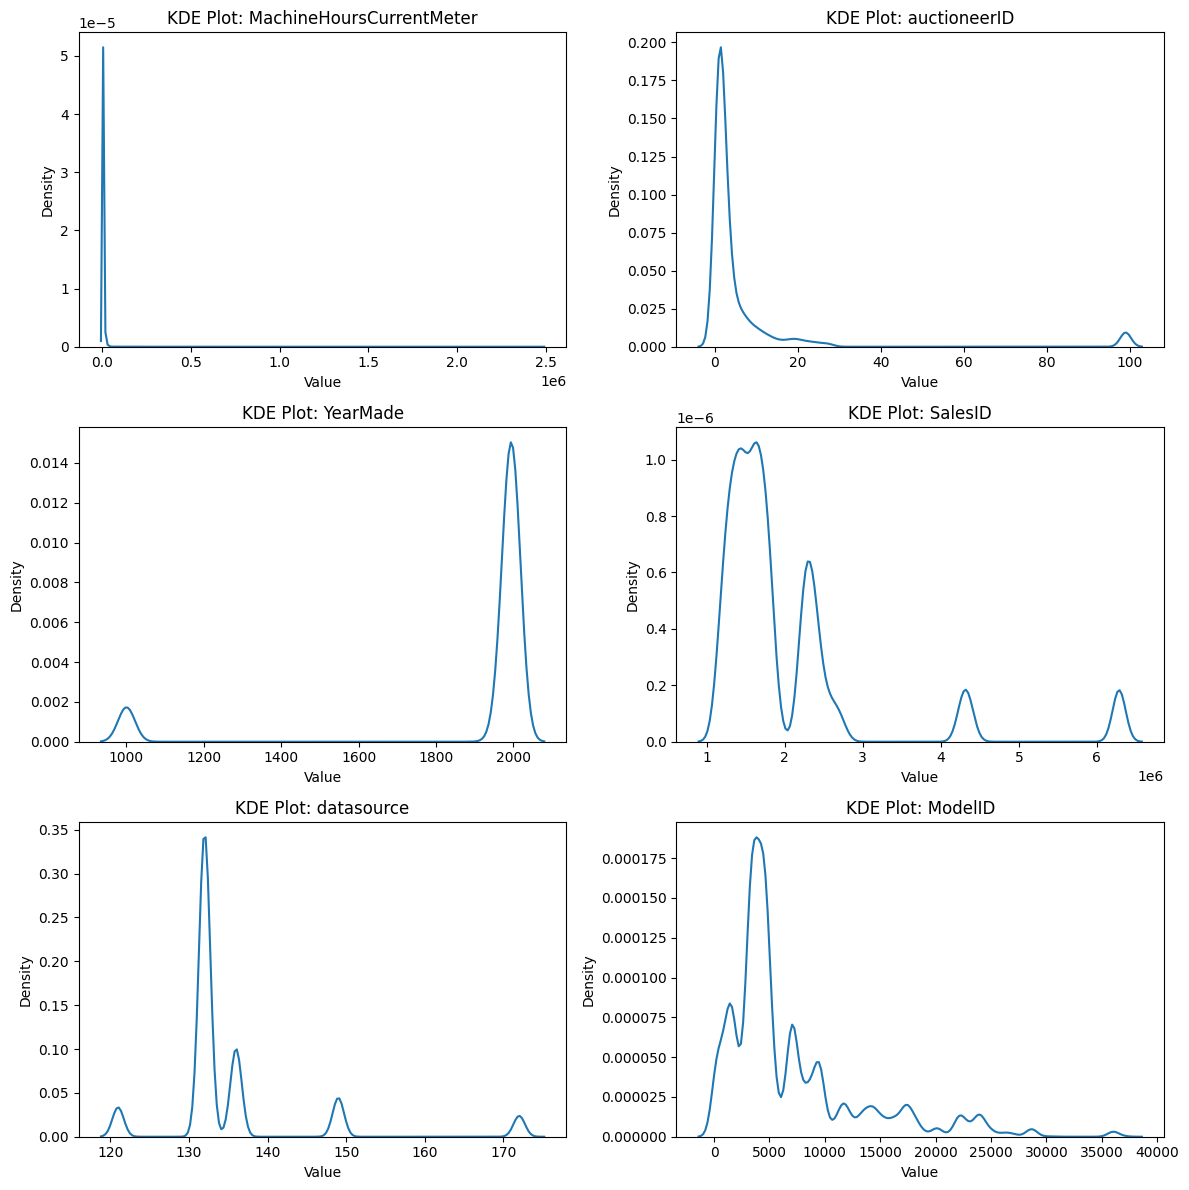

In [40]:
# KDE plot for top skewed numerical features

plot_numerical_kde(
    df=train_validation,
    feature_list=top_skewed_features,
    cols=2,
    figure_height_per_row=4
)

> No way to use  Linear Model:💩🫤

### Skewness Summary Visualization

This plot summarizes the skewness values of the most skewed numerical features.

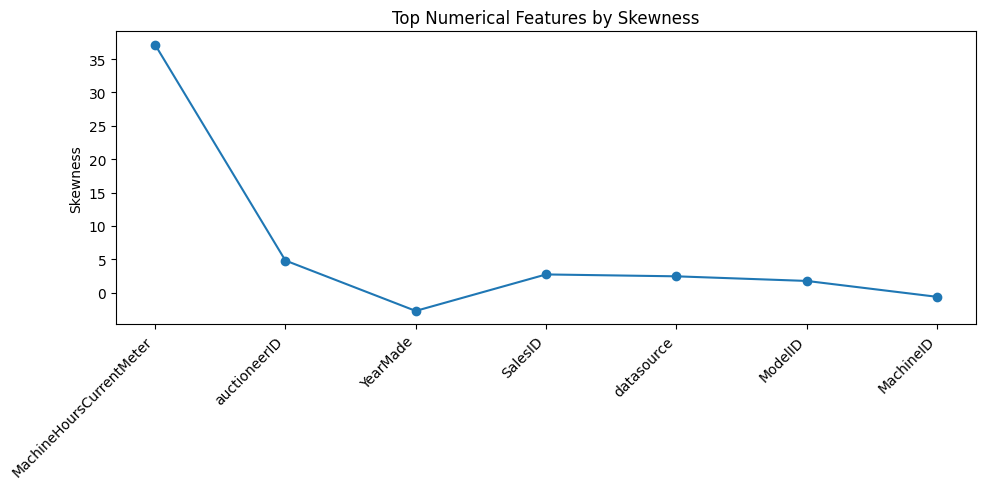

In [41]:
# Optional skewness summary plot

plot_df = numerical_distribution_shape_df.copy()
plot_df["Abs_Skewness"] = plot_df["Skewness"].abs()
plot_df = plot_df.sort_values("Abs_Skewness", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Feature_Name"], plot_df["Skewness"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Skewness")
plt.title("Top Numerical Features by Skewness")
plt.tight_layout()
plt.show()

## 1.1.8 Special Value Pattern

This section helps us identify special numeric value patterns that may affect later feature engineering.

- **Zero_Count**: Total number of zero values in the feature
- **Zero_Percentage**: Percentage of zero values in the feature
- **Negative_Count**: Total number of negative values in the feature
- **Negative_Percentage**: Percentage of negative values in the feature

In [42]:
# Helper function: numerical special value pattern summary

def create_numerical_special_value_pattern_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create a summary dataframe for zero-heavy and negative-heavy patterns
    in numerical features.
    """
    records = []
    total_rows = df.shape[0]

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce")

        zero_count = (series == 0).sum()
        negative_count = (series < 0).sum()

        zero_percentage = (zero_count / total_rows) * 100 if total_rows > 0 else 0
        negative_percentage = (negative_count / total_rows) * 100 if total_rows > 0 else 0

        records.append({
            "Feature_Name": feature,
            "Zero_Count": zero_count,
            "Zero_Percentage": zero_percentage,
            "Negative_Count": negative_count,
            "Negative_Percentage": negative_percentage
        })

    numerical_special_value_pattern_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_special_value_pattern_df

In [43]:
# Numerical special value pattern dataframe

numerical_special_value_pattern_df = create_numerical_special_value_pattern_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Special Value Pattern Shape:", numerical_special_value_pattern_df.shape)
display(numerical_special_value_pattern_df.head(20))

Numerical Special Value Pattern Shape: (7, 5)


,Feature_Name,Zero_Count,Zero_Percentage,Negative_Count,Negative_Percentage
0,SalesID,0,0.0000,0,0.0000
1,MachineID,2,0.0005,0,0.0000
2,ModelID,0,0.0000,0,0.0000
3,datasource,0,0.0000,0,0.0000
4,auctioneerID,536,0.1299,0,0.0000
5,YearMade,0,0.0000,0,0.0000
6,MachineHoursCurrentMeter,73834,17.8906,0,0.0000


### Zero Value Visualization

This chart highlights numerical features with the highest percentage of zero values.  
It helps us identify zero-heavy features that may behave differently from typical continuous variables.

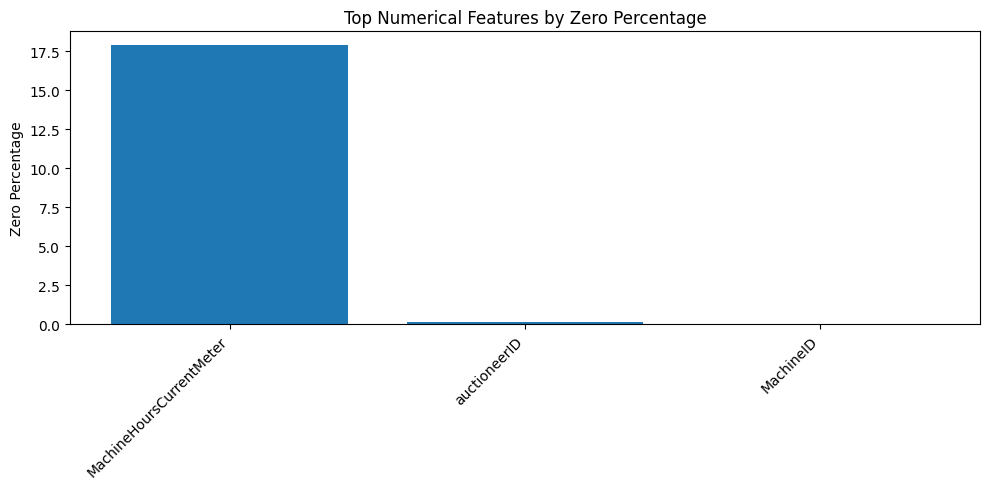

In [44]:
# Zero percentage plot

plot_df = numerical_special_value_pattern_df[
    numerical_special_value_pattern_df["Zero_Count"] > 0
].sort_values("Zero_Percentage", ascending=False).head(10)

if not plot_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["Feature_Name"], plot_df["Zero_Percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Zero Percentage")
    plt.title("Top Numerical Features by Zero Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No zero values found in numerical features.")

### Negative Value Visualization

This chart highlights numerical features with the highest percentage of negative values.  
It helps us identify sign-related patterns that may need business-rule review later.

In [45]:
# Negative percentage plot

plot_df = numerical_special_value_pattern_df[
    numerical_special_value_pattern_df["Negative_Count"] > 0
].sort_values("Negative_Percentage", ascending=False).head(10)

if not plot_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["Feature_Name"], plot_df["Negative_Percentage"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Negative Percentage")
    plt.title("Top Numerical Features by Negative Percentage")
    plt.tight_layout()
    plt.show()
else:
    print("No negative values found in numerical features.")

No negative values found in numerical features.


### Zero vs Negative Pattern Comparison

This plot compares zero-heavy and negative-heavy behavior across selected numerical features.

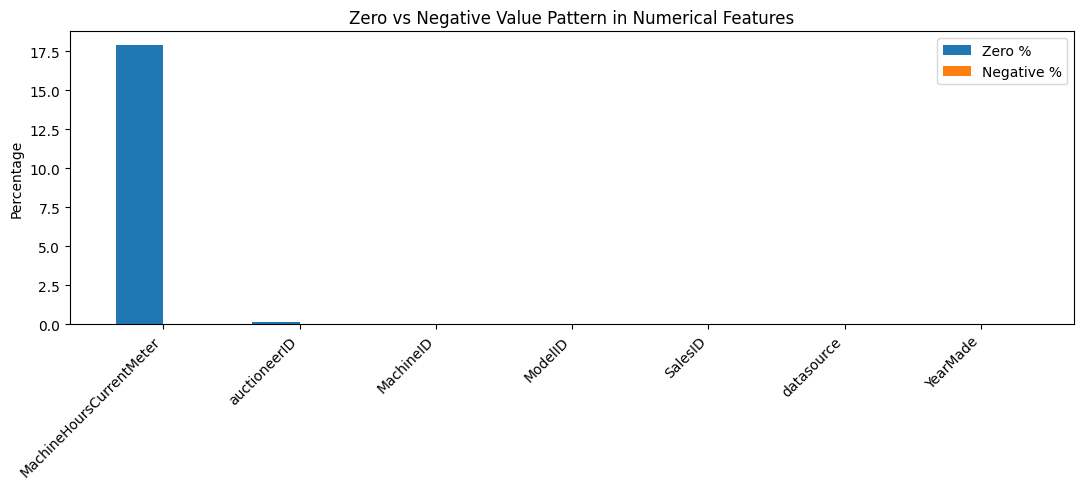

In [46]:
# Zero vs negative comparison plot

plot_df = numerical_special_value_pattern_df.copy()
plot_df["Combined_Special_Value_Percentage"] = (
    plot_df["Zero_Percentage"] + plot_df["Negative_Percentage"]
)
plot_df = plot_df.sort_values("Combined_Special_Value_Percentage", ascending=False).head(10)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, plot_df["Zero_Percentage"], width=width, label="Zero %")
plt.bar(x + width / 2, plot_df["Negative_Percentage"], width=width, label="Negative %")

plt.xticks(x, plot_df["Feature_Name"], rotation=45, ha="right")
plt.ylabel("Percentage")
plt.title("Zero vs Negative Value Pattern in Numerical Features")
plt.legend()
plt.tight_layout()
plt.show()

## 1.1.9 Outlier Summary

This section helps us identify potential outliers in numerical features using the IQR rule.

- **IQR_Outlier_Count**: Total number of observations outside the IQR-based bounds
- **IQR_Outlier_Percentage**: Percentage of outlier observations in the feature
- **Lower_Bound_IQR**: Lower threshold for IQR-based outlier detection
- **Upper_Bound_IQR**: Upper threshold for IQR-based outlier detection

In [47]:
# Helper function: numerical IQR outlier summary

def create_numerical_outlier_summary_df(
    df: pd.DataFrame,
    numerical_features: list
) -> pd.DataFrame:
    """
    Create an IQR-based outlier summary dataframe for numerical features.
    """
    records = []
    total_rows = df.shape[0]

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce").dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_mask = (series < lower_bound) | (series > upper_bound)
        outlier_count = outlier_mask.sum()
        outlier_percentage = (outlier_count / total_rows) * 100 if total_rows > 0 else 0

        records.append({
            "Feature_Name": feature,
            "Lower_Bound_IQR": lower_bound,
            "Upper_Bound_IQR": upper_bound,
            "IQR_Outlier_Count": outlier_count,
            "IQR_Outlier_Percentage": outlier_percentage
        })

    numerical_outlier_summary_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_outlier_summary_df

In [48]:
# Numerical outlier summary dataframe

numerical_outlier_summary_df = create_numerical_outlier_summary_df(
    df=train_validation,
    numerical_features=numerical_features
)

print("Numerical Outlier Summary Shape:", numerical_outlier_summary_df.shape)
display(numerical_outlier_summary_df.head(20))

Numerical Outlier Summary Shape: (7, 5)


,Feature_Name,Lower_Bound_IQR,Upper_Bound_IQR,IQR_Outlier_Count,IQR_Outlier_Percentage
0,SalesID,163225.6250,3519684.6250,33806,8.1915
1,MachineID,504364.2500,2062308.2500,50430,12.2196
2,ModelID,-5196.0000,17356.0000,33895,8.2130
3,datasource,126.0000,142.0000,76431,18.5198
4,auctioneerID,-3.5000,8.5000,56429,13.6732
5,YearMade,1961.0000,2025.0000,39764,9.6351
6,MachineHoursCurrentMeter,-4813.5000,8022.5000,13017,3.1541


### Outlier Visualization

The following plot uses boxplots to visualize the numerical features with the highest IQR-based outlier burden.  
This gives a direct visual view of spread, quartiles, and potential extreme values.

In [49]:
# Helper function: select top outlier-heavy features

def get_top_outlier_features(
    outlier_df: pd.DataFrame,
    top_n: int = 8
) -> list:
    """
    Select top numerical features based on IQR outlier percentage.
    """
    top_features = (
        outlier_df
        .sort_values("IQR_Outlier_Percentage", ascending=False)
        .head(top_n)["Feature_Name"]
        .tolist()
    )
    return top_features

In [50]:
# Helper function: boxplot for selected outlier-heavy numerical features

def plot_outlier_boxplot(
    df: pd.DataFrame,
    feature_list: list,
    figure_size: tuple = (12, 6)
) -> None:
    """
    Plot horizontal boxplots for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for boxplot.")
        return

    plot_df = df[feature_list].copy()
    plot_df = plot_df.melt(var_name="Feature_Name", value_name="Value").dropna()

    plt.figure(figsize=figure_size)
    sns.boxplot(data=plot_df, x="Value", y="Feature_Name")
    plt.title("Boxplot of Numerical Features with Highest Outlier Burden")
    plt.xlabel("Value")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

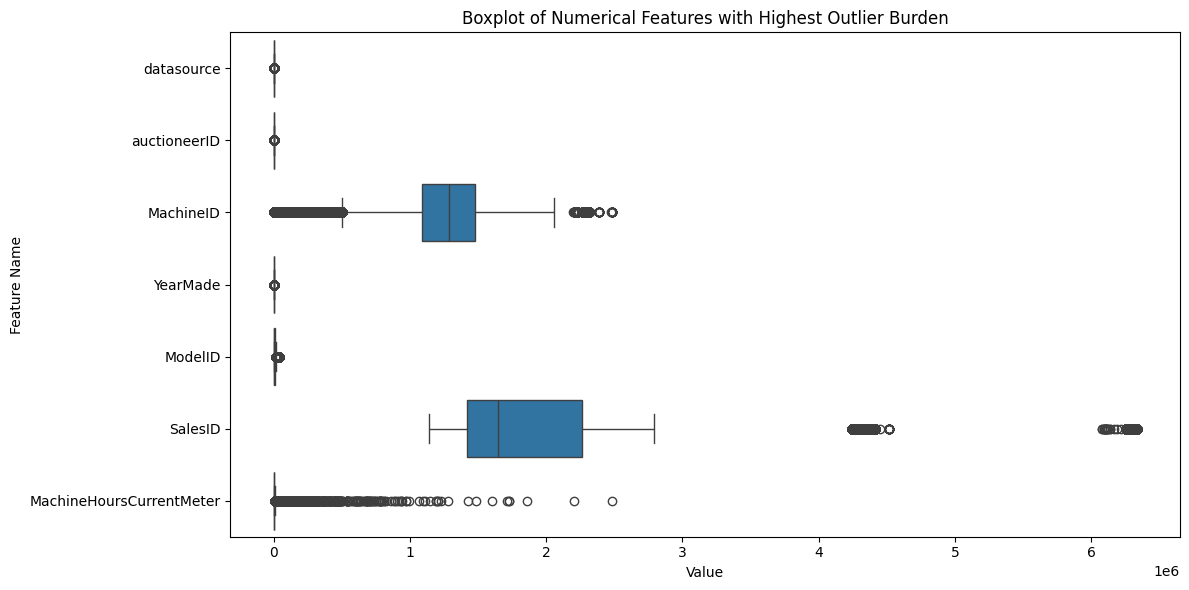

In [51]:
# Boxplot for top outlier-heavy numerical features

top_outlier_features = get_top_outlier_features(
    outlier_df=numerical_outlier_summary_df,
    top_n=8
)

plot_outlier_boxplot(
    df=train_validation,
    feature_list=top_outlier_features,
    figure_size=(12, 6)
)

### Boxenplot Visualization

This plot complements the boxplot by showing more detail in the tails of the distribution, which is useful for outlier-heavy features.

In [52]:
# Helper function: boxenplot for selected outlier-heavy numerical features

def plot_outlier_boxenplot(
    df: pd.DataFrame,
    feature_list: list,
    figure_size: tuple = (12, 6)
) -> None:
    """
    Plot horizontal boxenplots for selected numerical features.
    """
    if len(feature_list) == 0:
        print("No features available for boxenplot.")
        return

    plot_df = df[feature_list].copy()
    plot_df = plot_df.melt(var_name="Feature_Name", value_name="Value").dropna()

    plt.figure(figsize=figure_size)
    sns.boxenplot(data=plot_df, x="Value", y="Feature_Name")
    plt.title("Boxenplot of Numerical Features with Highest Outlier Burden")
    plt.xlabel("Value")
    plt.ylabel("Feature Name")
    plt.tight_layout()
    plt.show()

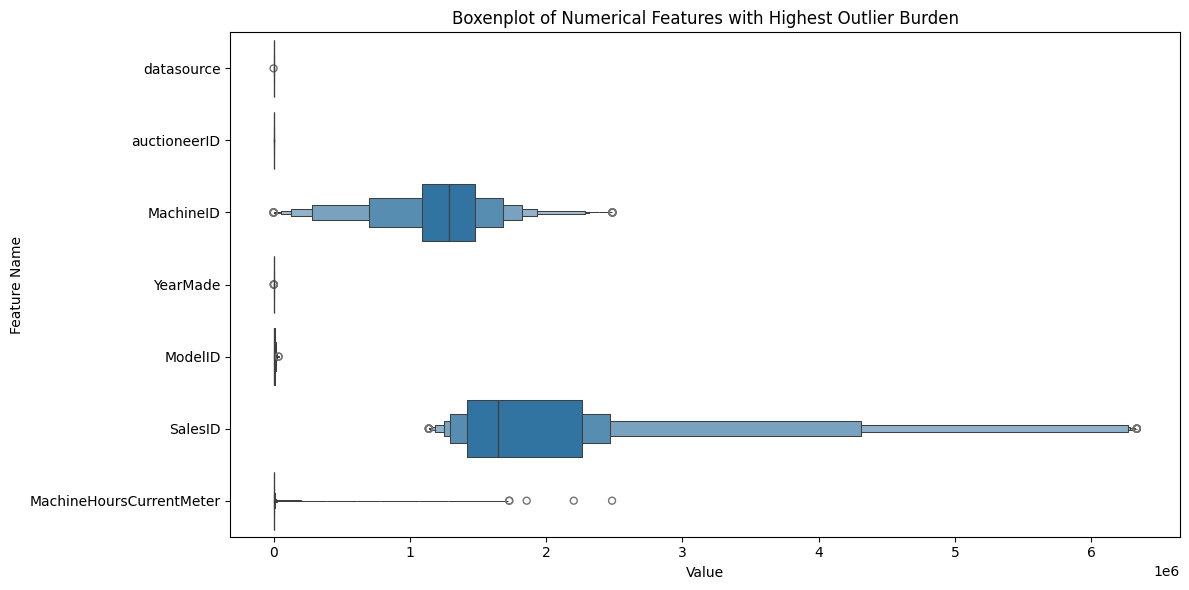

In [53]:
# Boxenplot for top outlier-heavy numerical features

plot_outlier_boxenplot(
    df=train_validation,
    feature_list=top_outlier_features,
    figure_size=(12, 6)
)

### Outlier Burden Summary

This chart summarizes the numerical features with the highest IQR-based outlier percentages.

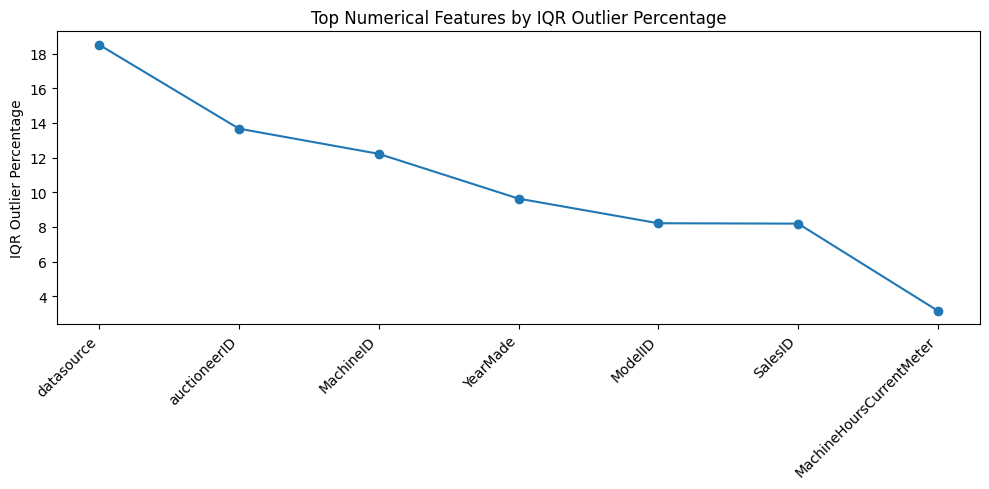

In [54]:
# Optional outlier percentage summary plot

plot_df = numerical_outlier_summary_df.sort_values("IQR_Outlier_Percentage", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Feature_Name"], plot_df["IQR_Outlier_Percentage"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("IQR Outlier Percentage")
plt.title("Top Numerical Features by IQR Outlier Percentage")
plt.tight_layout()
plt.show()

## 1.1.10 Stability / Variability Flags

This section helps us identify numerical features that have extremely low variability.

- **Constant_Flag**: Indicates whether a feature has only one unique usable value
- **Near_Constant_Flag**: Indicates whether one value dominates almost the entire feature distribution

In [55]:
# Helper function: numerical stability / variability flags

def create_numerical_stability_flags_df(
    df: pd.DataFrame,
    numerical_features: list,
    near_constant_threshold: float = 0.95
) -> pd.DataFrame:
    """
    Create a summary dataframe for constant and near-constant numerical features.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    numerical_features : list
        List of numerical feature names.
    near_constant_threshold : float, optional
        Threshold for dominant value percentage to flag a feature as near-constant.

    Returns
    -------
    pd.DataFrame
        Numerical stability / variability flags dataframe.
    """
    records = []

    for feature in numerical_features:
        series = pd.to_numeric(df[feature], errors="coerce").dropna()

        unique_count = series.nunique(dropna=True)

        if not series.empty:
            top_frequency = series.value_counts(normalize=True, dropna=True).iloc[0]
        else:
            top_frequency = np.nan

        constant_flag = unique_count == 1
        near_constant_flag = (top_frequency >= near_constant_threshold) if pd.notna(top_frequency) else False

        if constant_flag:
            stability_status = "Constant"
        elif near_constant_flag:
            stability_status = "Near Constant"
        else:
            stability_status = "Variable"

        records.append({
            "Feature_Name": feature,
            "Unique_Usable_Value_Count": unique_count,
            "Top_Value_Frequency": top_frequency,
            "Constant_Flag": constant_flag,
            "Near_Constant_Flag": near_constant_flag,
            "Stability_Status": stability_status
        })

    numerical_stability_flags_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_stability_flags_df

In [56]:
# Numerical stability / variability flags dataframe

numerical_stability_flags_df = create_numerical_stability_flags_df(
    df=train_validation,
    numerical_features=numerical_features,
    near_constant_threshold=0.95
)

print("Numerical Stability Flags Shape:", numerical_stability_flags_df.shape)
display(numerical_stability_flags_df.head(20))

Numerical Stability Flags Shape: (7, 6)


,Feature_Name,Unique_Usable_Value_Count,Top_Value_Frequency,Constant_Flag,Near_Constant_Flag,Stability_Status
0,SalesID,412698,0.0000,False,False,Variable
1,MachineID,348808,0.0001,False,False,Variable
2,ModelID,5281,0.0130,False,False,Variable
3,datasource,6,0.6319,False,False,Variable
4,auctioneerID,30,0.4911,False,False,Variable
5,YearMade,73,0.0954,False,False,Variable
6,MachineHoursCurrentMeter,15633,0.5006,False,False,Variable


### Stability Visualization

The following chart summarizes how many numerical features are variable, near-constant, or constant.  
This helps us quickly identify low-information features before feature engineering or modeling.

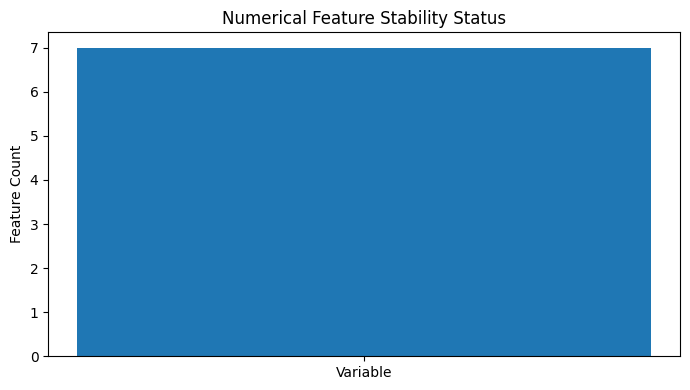

In [57]:
# Stability status count plot

plot_df = numerical_stability_flags_df["Stability_Status"].value_counts().reset_index()
plot_df.columns = ["Stability_Status", "Feature_Count"]

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Stability_Status"], plot_df["Feature_Count"])
plt.ylabel("Feature Count")
plt.title("Numerical Feature Stability Status")
plt.tight_layout()
plt.show()

### Dominant Value Visualization

This chart highlights numerical features where one value dominates most of the observations.  
It helps us identify near-constant features more directly.

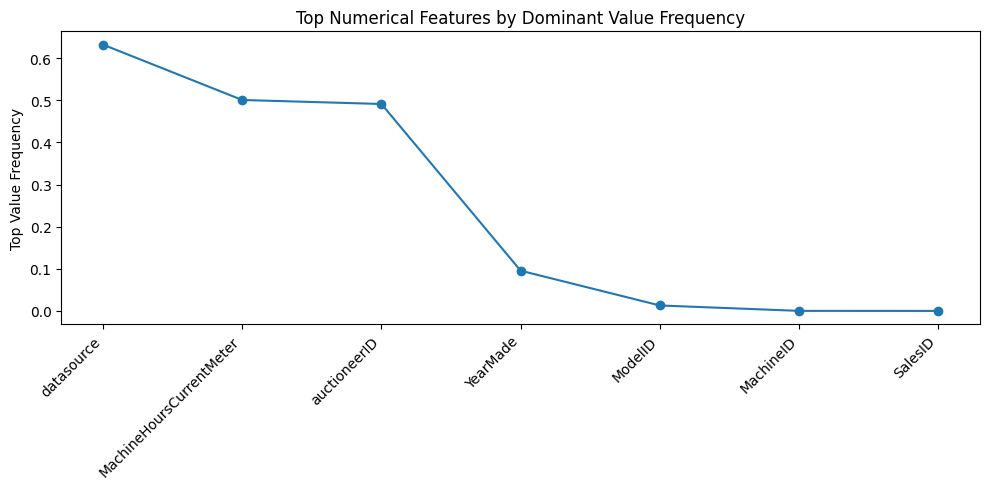

In [58]:
# Optional dominant value frequency plot

plot_df = numerical_stability_flags_df.sort_values("Top_Value_Frequency", ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["Feature_Name"], plot_df["Top_Value_Frequency"], marker="o")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Top Value Frequency")
plt.title("Top Numerical Features by Dominant Value Frequency")
plt.tight_layout()
plt.show()

### Low-Variability Feature Preview

The table below can be used to inspect constant and near-constant numerical features more closely.

In [59]:
numerical_stability_flags_df

,Feature_Name,Unique_Usable_Value_Count,Top_Value_Frequency,Constant_Flag,Near_Constant_Flag,Stability_Status
0,SalesID,412698,0.0000,False,False,Variable
1,MachineID,348808,0.0001,False,False,Variable
2,ModelID,5281,0.0130,False,False,Variable
3,datasource,6,0.6319,False,False,Variable
4,auctioneerID,30,0.4911,False,False,Variable
5,YearMade,73,0.0954,False,False,Variable
6,MachineHoursCurrentMeter,15633,0.5006,False,False,Variable


## 1.1.11 Base Feature Engineering Hints

This section provides first-pass feature engineering hints for numerical features based on their raw data behavior.

- **Suggested_Base_Imputation**: Suggested base missing-value handling strategy
- **Suggested_Base_Transformation**: Suggested base transformation strategy
- **Suggested_Base_Outlier_Action**: Suggested base outlier-handling strategy

In [60]:
# Helper function: numerical base feature engineering hints

def create_numerical_base_fe_hints_df(
    missing_df: pd.DataFrame,
    distribution_df: pd.DataFrame,
    outlier_df: pd.DataFrame,
    special_value_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Create a base feature engineering hint dataframe for numerical features
    using missingness, distribution shape, outlier burden, and special value patterns.
    """
    merged_df = (
        missing_df
        .merge(distribution_df, on="Feature_Name", how="left")
        .merge(outlier_df, on="Feature_Name", how="left")
        .merge(special_value_df, on="Feature_Name", how="left")
    )

    records = []

    for _, row in merged_df.iterrows():
        feature = row["Feature_Name"]

        missing_pct = row.get("Missing_Percentage", 0)
        skewness = row.get("Skewness", np.nan)
        outlier_pct = row.get("IQR_Outlier_Percentage", 0)
        zero_pct = row.get("Zero_Percentage", 0)
        negative_pct = row.get("Negative_Percentage", 0)

        # Imputation hint
        if missing_pct == 0:
            suggested_imputation = "No imputation needed"
        elif pd.notna(skewness) and abs(skewness) >= 1:
            suggested_imputation = "Median imputation preferred"
        elif outlier_pct >= 10:
            suggested_imputation = "Median imputation preferred"
        else:
            suggested_imputation = "Mean or median imputation"

        # Transformation hint
        if pd.notna(skewness) and skewness >= 1 and negative_pct == 0:
            suggested_transformation = "log1p candidate"
        elif pd.notna(skewness) and abs(skewness) >= 1 and negative_pct > 0:
            suggested_transformation = "Yeo-Johnson candidate"
        elif zero_pct >= 80:
            suggested_transformation = "Review before transformation (zero-heavy)"
        else:
            suggested_transformation = "No strong transformation needed"

        # Outlier action hint
        if outlier_pct == 0:
            suggested_outlier_action = "No clear outlier issue"
        elif outlier_pct < 5:
            suggested_outlier_action = "Review only"
        elif outlier_pct < 15:
            suggested_outlier_action = "Review and consider capping"
        else:
            suggested_outlier_action = "Strong review needed before capping"

        records.append({
            "Feature_Name": feature,
            "Suggested_Base_Imputation": suggested_imputation,
            "Suggested_Base_Transformation": suggested_transformation,
            "Suggested_Base_Outlier_Action": suggested_outlier_action
        })

    numerical_base_fe_hints_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_base_fe_hints_df

In [61]:
# Numerical base feature engineering hints dataframe

numerical_base_fe_hints_df = create_numerical_base_fe_hints_df(
    missing_df=numerical_missing_summary_df,
    distribution_df=numerical_distribution_shape_df,
    outlier_df=numerical_outlier_summary_df,
    special_value_df=numerical_special_value_pattern_df
)

print("Numerical Base FE Hints Shape:", numerical_base_fe_hints_df.shape)
display(numerical_base_fe_hints_df.head(20))

Numerical Base FE Hints Shape: (7, 4)


,Feature_Name,Suggested_Base_Imputation,Suggested_Base_Transformation,Suggested_Base_Outlier_Action
0,MachineHoursCurrentMeter,Median imputation preferred,log1p candidate,Review only
1,auctioneerID,Median imputation preferred,log1p candidate,Review and consider capping
2,SalesID,No imputation needed,log1p candidate,Review and consider capping
3,MachineID,No imputation needed,No strong transformation needed,Review and consider capping
4,ModelID,No imputation needed,log1p candidate,Review and consider capping
5,datasource,No imputation needed,log1p candidate,Strong review needed before capping
6,YearMade,No imputation needed,No strong transformation needed,Review and consider capping


### Imputation Hint Visualization

This chart summarizes the suggested base imputation strategies across numerical features.

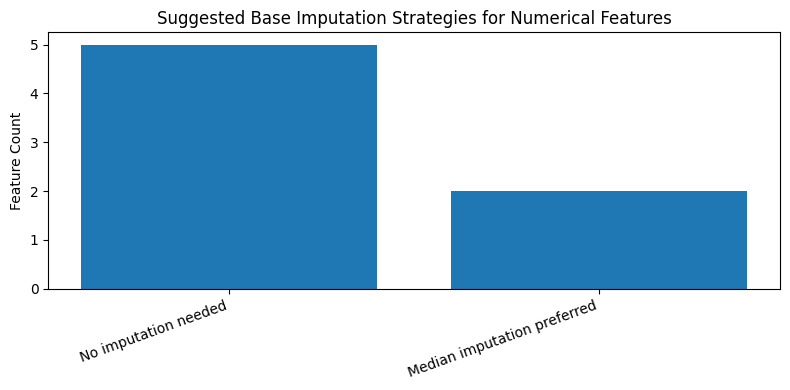

In [62]:
# Imputation hint count plot

plot_df = numerical_base_fe_hints_df["Suggested_Base_Imputation"].value_counts().reset_index()
plot_df.columns = ["Suggested_Base_Imputation", "Feature_Count"]

plt.figure(figsize=(8, 4))
plt.bar(plot_df["Suggested_Base_Imputation"], plot_df["Feature_Count"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Feature Count")
plt.title("Suggested Base Imputation Strategies for Numerical Features")
plt.tight_layout()
plt.show()

### Transformation Hint Visualization

This chart summarizes the suggested base transformation strategies for numerical features.

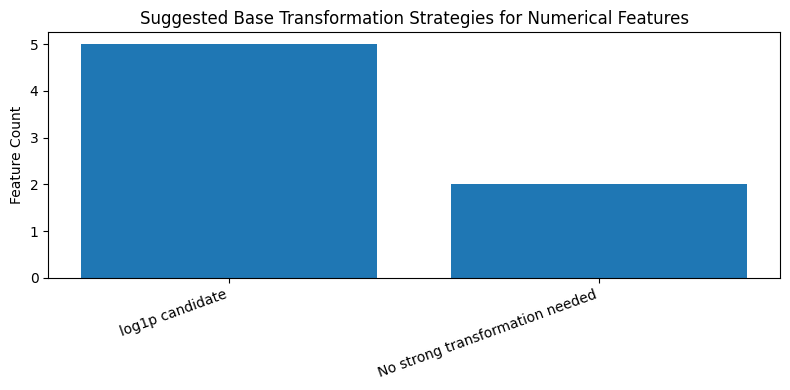

In [63]:
# Transformation hint count plot

plot_df = numerical_base_fe_hints_df["Suggested_Base_Transformation"].value_counts().reset_index()
plot_df.columns = ["Suggested_Base_Transformation", "Feature_Count"]

plt.figure(figsize=(8, 4))
plt.bar(plot_df["Suggested_Base_Transformation"], plot_df["Feature_Count"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Feature Count")
plt.title("Suggested Base Transformation Strategies for Numerical Features")
plt.tight_layout()
plt.show()

### Outlier Action Visualization

This chart summarizes the suggested base outlier-handling actions for numerical features.

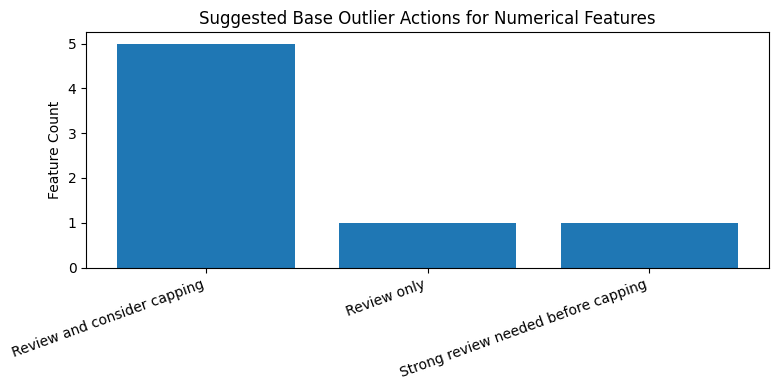

In [64]:
# Outlier action hint count plot

plot_df = numerical_base_fe_hints_df["Suggested_Base_Outlier_Action"].value_counts().reset_index()
plot_df.columns = ["Suggested_Base_Outlier_Action", "Feature_Count"]

plt.figure(figsize=(8, 4))
plt.bar(plot_df["Suggested_Base_Outlier_Action"], plot_df["Feature_Count"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Feature Count")
plt.title("Suggested Base Outlier Actions for Numerical Features")
plt.tight_layout()
plt.show()

## 1.1.12 Data Quality Notes

This section highlights raw data quality concerns in numerical features and suggests simple first-pass cleaning actions.

- **Data_Quality_Issues**: Possible raw-data concerns such as zero-heavy pattern, negative values, or unusual distributions
- **Cleaning_Action**: A short plain-English suggestion for first-pass cleaning or review

In [65]:
# Helper function: numerical data quality notes

def create_numerical_data_quality_notes_df(
    missing_df: pd.DataFrame,
    uniqueness_df: pd.DataFrame,
    distribution_df: pd.DataFrame,
    special_value_df: pd.DataFrame,
    outlier_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Create raw data quality notes and first-pass cleaning actions
    for numerical features.
    """
    merged_df = (
        missing_df
        .merge(uniqueness_df, on="Feature_Name", how="left")
        .merge(distribution_df, on="Feature_Name", how="left")
        .merge(special_value_df, on="Feature_Name", how="left")
        .merge(outlier_df, on="Feature_Name", how="left")
    )

    records = []

    for _, row in merged_df.iterrows():
        feature = row["Feature_Name"]

        missing_pct = row.get("Missing_Percentage", 0)
        unique_count = row.get("Unique_Count", np.nan)
        looks_like_categorical = row.get("Looks_Like_Categorical_Flag", False)
        skewness = row.get("Skewness", np.nan)
        zero_pct = row.get("Zero_Percentage", 0)
        negative_pct = row.get("Negative_Percentage", 0)
        outlier_pct = row.get("IQR_Outlier_Percentage", 0)

        issues = []
        actions = []

        if missing_pct > 0:
            issues.append("Missing Values Present")
            actions.append("Review missing-value handling strategy")

        if looks_like_categorical:
            issues.append("May Behave Like Categorical")
            actions.append("Review whether categorical treatment is more appropriate")

        if pd.notna(skewness) and abs(skewness) >= 1:
            issues.append("High Skewness")
            actions.append("Review whether transformation is needed")

        if zero_pct >= 50:
            issues.append("Zero-Heavy Pattern")
            actions.append("Check whether zeros are meaningful or need special handling")

        if negative_pct > 0:
            issues.append("Negative Values Present")
            actions.append("Review whether negative values are valid by business logic")

        if outlier_pct >= 10:
            issues.append("High Outlier Burden")
            actions.append("Review whether capping or special handling is needed")

        if unique_count == 1:
            issues.append("Constant Feature")
            actions.append("Consider dropping the feature if it has no useful variation")

        if not issues:
            issues.append("No Major Raw Data Issue Detected")
            actions.append("No immediate cleaning action required")

        records.append({
            "Feature_Name": feature,
            "Data_Quality_Issues": " | ".join(issues),
            "Cleaning_Action": " | ".join(actions)
        })

    numerical_data_quality_notes_df = pd.DataFrame(records).reset_index(drop=True)
    return numerical_data_quality_notes_df

In [66]:
# Numerical data quality notes dataframe

numerical_data_quality_notes_df = create_numerical_data_quality_notes_df(
    missing_df=numerical_missing_summary_df,
    uniqueness_df=numerical_uniqueness_summary_df,
    distribution_df=numerical_distribution_shape_df,
    special_value_df=numerical_special_value_pattern_df,
    outlier_df=numerical_outlier_summary_df
)

print("Numerical Data Quality Notes Shape:", numerical_data_quality_notes_df.shape)
display(numerical_data_quality_notes_df.head(20))

Numerical Data Quality Notes Shape: (7, 3)


,Feature_Name,Data_Quality_Issues,Cleaning_Action
0,MachineHoursCurrentMeter,Missing Values Present | High Skewness,Review missing-value handling strategy | Revie...
1,auctioneerID,Missing Values Present | May Behave Like Categ...,Review missing-value handling strategy | Revie...
2,SalesID,High Skewness,Review whether transformation is needed
3,MachineID,High Outlier Burden,Review whether capping or special handling is ...
4,ModelID,High Skewness,Review whether transformation is needed
5,datasource,May Behave Like Categorical | High Skewness | ...,Review whether categorical treatment is more a...
6,YearMade,May Behave Like Categorical | High Skewness,Review whether categorical treatment is more a...


### Data Quality Issue Visualization

This chart summarizes the most common raw data quality issues across numerical features.

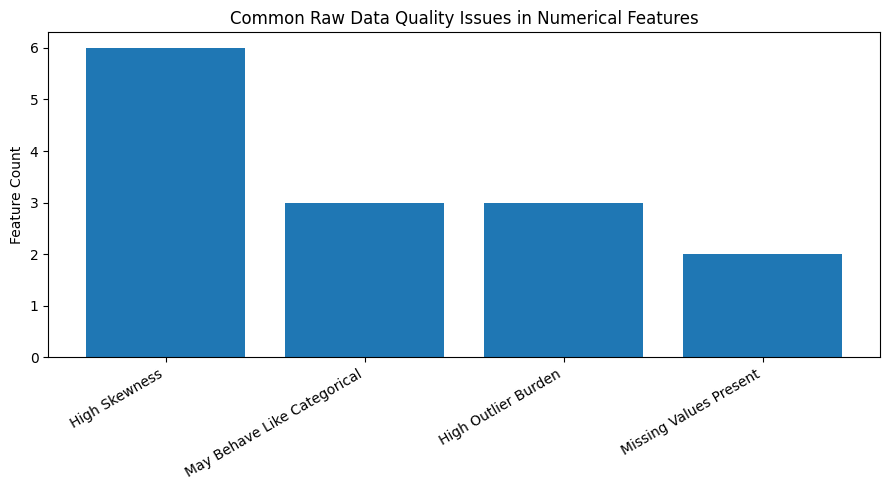

In [67]:
# Data quality issue count plot

issue_series = (
    numerical_data_quality_notes_df["Data_Quality_Issues"]
    .str.split(" | ", regex=False)
    .explode()
    .value_counts()
    .reset_index()
)
issue_series.columns = ["Data_Quality_Issue", "Feature_Count"]

plt.figure(figsize=(9, 5))
plt.bar(issue_series["Data_Quality_Issue"], issue_series["Feature_Count"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Feature Count")
plt.title("Common Raw Data Quality Issues in Numerical Features")
plt.tight_layout()
plt.show()

### Cleaning Action Visualization

This chart summarizes the most common first-pass cleaning suggestions across numerical features.

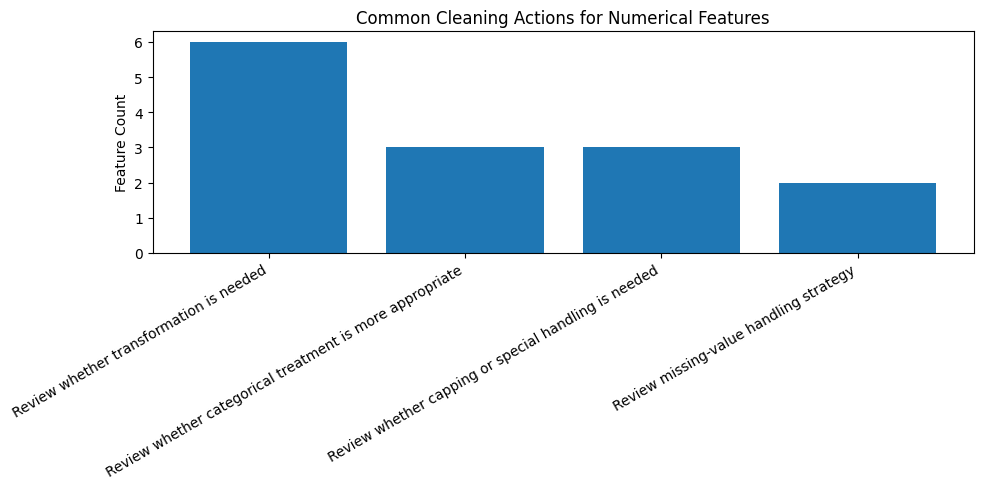

In [68]:
# Cleaning action count plot

action_series = (
    numerical_data_quality_notes_df["Cleaning_Action"]
    .str.split(" | ", regex=False)
    .explode()
    .value_counts()
    .reset_index()
)
action_series.columns = ["Cleaning_Action", "Feature_Count"]

plt.figure(figsize=(10, 5))
plt.bar(action_series["Cleaning_Action"], action_series["Feature_Count"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Feature Count")
plt.title("Common Cleaning Actions for Numerical Features")
plt.tight_layout()
plt.show()

### Focused Review Table

The table below can be used to inspect numerical features with stronger raw-data quality concerns.

In [69]:
# Optional focused review table

numerical_data_quality_notes_df[
    numerical_data_quality_notes_df["Data_Quality_Issues"] != "No Major Raw Data Issue Detected"
].head(20)

,Feature_Name,Data_Quality_Issues,Cleaning_Action
0,MachineHoursCurrentMeter,Missing Values Present | High Skewness,Review missing-value handling strategy | Revie...
1,auctioneerID,Missing Values Present | May Behave Like Categ...,Review missing-value handling strategy | Revie...
2,SalesID,High Skewness,Review whether transformation is needed
3,MachineID,High Outlier Burden,Review whether capping or special handling is ...
4,ModelID,High Skewness,Review whether transformation is needed
5,datasource,May Behave Like Categorical | High Skewness | ...,Review whether categorical treatment is more a...
6,YearMade,May Behave Like Categorical | High Skewness,Review whether categorical treatment is more a...


## 1.1.13 Full Numerical Raw Feature Report

In this step, we combine all previously created numerical summary tables into a single full raw feature report.

This final report brings together:
- feature identity
- missing value summary
- uniqueness and feature nature
- central tendency
- dispersion and spread
- percentile summary
- distribution shape
- special value patterns
- outlier summary
- stability / variability flags
- base feature engineering hints
- data quality notes

This merged report becomes the main reusable numerical raw feature profile for later analysis and feature engineering.

In [70]:
# Helper function: merge all numerical report sections into one final report

def create_full_numerical_raw_feature_report_df(
    numerical_feature_identity_df: pd.DataFrame,
    numerical_missing_summary_df: pd.DataFrame,
    numerical_uniqueness_summary_df: pd.DataFrame,
    numerical_central_tendency_df: pd.DataFrame,
    numerical_dispersion_summary_df: pd.DataFrame,
    numerical_percentile_summary_df: pd.DataFrame,
    numerical_distribution_shape_df: pd.DataFrame,
    numerical_special_value_pattern_df: pd.DataFrame,
    numerical_outlier_summary_df: pd.DataFrame,
    numerical_stability_flags_df: pd.DataFrame,
    numerical_base_fe_hints_df: pd.DataFrame,
    numerical_data_quality_notes_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Merge all numerical raw feature report sections into one final dataframe.
    """
    full_report_df = numerical_feature_identity_df.copy()

    merge_dfs = [
        numerical_missing_summary_df,
        numerical_uniqueness_summary_df,
        numerical_central_tendency_df,
        numerical_dispersion_summary_df,
        numerical_percentile_summary_df,
        numerical_distribution_shape_df,
        numerical_special_value_pattern_df,
        numerical_outlier_summary_df,
        numerical_stability_flags_df,
        numerical_base_fe_hints_df,
        numerical_data_quality_notes_df
    ]

    for section_df in merge_dfs:
        full_report_df = full_report_df.merge(
            section_df,
            on="Feature_Name",
            how="left"
        )

    return full_report_df

In [71]:
# Final merged numerical raw feature report dataframe

numerical_raw_feature_report_df = create_full_numerical_raw_feature_report_df(
    numerical_feature_identity_df=numerical_feature_identity_df,
    numerical_missing_summary_df=numerical_missing_summary_df,
    numerical_uniqueness_summary_df=numerical_uniqueness_summary_df,
    numerical_central_tendency_df=numerical_central_tendency_df,
    numerical_dispersion_summary_df=numerical_dispersion_summary_df,
    numerical_percentile_summary_df=numerical_percentile_summary_df,
    numerical_distribution_shape_df=numerical_distribution_shape_df,
    numerical_special_value_pattern_df=numerical_special_value_pattern_df,
    numerical_outlier_summary_df=numerical_outlier_summary_df,
    numerical_stability_flags_df=numerical_stability_flags_df,
    numerical_base_fe_hints_df=numerical_base_fe_hints_df,
    numerical_data_quality_notes_df=numerical_data_quality_notes_df
)

print("Full Numerical Raw Feature Report Shape:", numerical_raw_feature_report_df.shape)
display(numerical_raw_feature_report_df.head(20))

Full Numerical Raw Feature Report Shape: (7, 45)


,Feature_Name,Dtype,Primary_Feature_Type,Missing_Count,Missing_Percentage,Non_Null_Count,Unique_Count,Unique_Ratio,Looks_Like_Categorical_Flag,Mean,Median,Mode,Std,Min,Max,Range,Q1 (25%),Q3 (75%),IQR,P01,P05,P95,P99,Skewness,Skewness_Level,Kurtosis,Distribution_Shape,Zero_Count,Zero_Percentage,Negative_Count,Negative_Percentage,Lower_Bound_IQR,Upper_Bound_IQR,IQR_Outlier_Count,IQR_Outlier_Percentage,Unique_Usable_Value_Count,Top_Value_Frequency,Constant_Flag,Near_Constant_Flag,Stability_Status,Suggested_Base_Imputation,Suggested_Base_Transformation,Suggested_Base_Outlier_Action,Data_Quality_Issues,Cleaning_Action
0,MachineHoursCurrentMeter,float64,Numerical,265194,64.2586,147504,15633,0.0379,False,3522.9883,0.0000,0.0000,27169.9287,0.0000,2483300.0000,2483300.0000,0.0000,3209.0000,3209.0000,0.0000,0.0000,10746.0000,22696.6100,37.1716,Highly Right-Skewed,1964.1945,Right-Skewed,73834,17.8906,0,0.0000,-4813.5000,8022.5000,13017,3.1541,15633,0.5006,False,False,Variable,Median imputation preferred,log1p candidate,Review only,Missing Values Present | High Skewness,Review missing-value handling strategy | Revie...
1,MachineID,int64,Numerical,0,0.0000,412698,348808,0.8452,False,1230061.4366,1284397.0000,2283592.0000,453953.2579,0.0000,2486330.0000,2486330.0000,1088593.2500,1478079.2500,389486.0000,30877.9100,217982.8500,1864816.3500,2296523.0000,-0.6345,Moderately Left-Skewed,0.9091,Left-Skewed,2,0.0005,0,0.0000,504364.2500,2062308.2500,50430,12.2196,348808,0.0001,False,False,Variable,No imputation needed,No strong transformation needed,Review and consider capping,High Outlier Burden,Review whether capping or special handling is ...
2,ModelID,int64,Numerical,0,0.0000,412698,5281,0.0128,False,6947.2018,4605.0000,4605.0000,6280.8250,28.0000,37198.0000,37170.0000,3261.0000,8899.0000,5638.0000,108.0000,590.0000,22114.0000,28439.0000,1.7467,Highly Right-Skewed,3.0409,Right-Skewed,0,0.0000,0,0.0000,-5196.0000,17356.0000,33895,8.2130,5281,0.0130,False,False,Variable,No imputation needed,log1p candidate,Review and consider capping,High Skewness,Review whether transformation is needed
3,SalesID,int64,Numerical,0,0.0000,412698,412698,1.0000,False,2011161.1636,1645852.5000,1139246.0000,1080067.7245,1139246.0000,6333349.0000,5194103.0000,1421897.7500,2261012.5000,839114.7500,1153079.8200,1210925.8500,4357166.8000,6302738.0300,2.7208,Highly Right-Skewed,7.4134,Right-Skewed,0,0.0000,0,0.0000,163225.6250,3519684.6250,33806,8.1915,412698,0.0000,False,False,Variable,No imputation needed,log1p candidate,Review and consider capping,High Skewness,Review whether transformation is needed
4,YearMade,int64,Numerical,0,0.0000,412698,73,0.0002,True,1899.0496,1995.0000,1000.0000,292.1902,1000.0000,2014.0000,1014.0000,1985.0000,2001.0000,16.0000,1000.0000,1000.0000,2005.0000,2007.0000,-2.7486,Highly Left-Skewed,5.5661,Left-Skewed,0,0.0000,0,0.0000,1961.0000,2025.0000,39764,9.6351,73,0.0954,False,False,Variable,No imputation needed,No strong transformation needed,Review and consider capping,May Behave Like Categorical | High Skewness,Review whether categorical treatment is more a...
5,auctioneerID,float64,Numerical,20136,4.8791,392562,30,0.0001,True,6.5853,2.0000,1.0000,17.1584,0.0000,99.0000,99.0000,1.0000,4.0000,3.0000,1.0000,1.0000,22.0000,99.0000,4.8088,Highly Right-Skewed,22.8554,Right-Skewed,536,0.1299,0,0.0000,-3.5000,8.5000,56429,13.6732,30,0.4911,False,False,Variable,Median imputation preferred,log1p candidate,Review and consider capping,Missing Values Present | May Behave Like Categ...,Review missing-value handling strategy | Revie...
6,datasource,int64,Numerical,0,0.0000,412698,6,0.0000,True,135.1694,132.0000,132.0000,9.6467,121.0000,173.0000,52.0000,132.0000,136.0000,4.0000,121.0000,121.0000,149.0000,172.0000,2.4381,Highly Right-Skewed,6.8564,Right-Skewed,0,0.0000,0,0.0000,126.0000,142.0000,76431,18.5198,6,0.6319,False,False,Variable,No imputation needed,log1p candidate,Strong review needed before capping,May Behave Like Categorical | High Skewness | 

In [72]:
# Optional: reorder columns for a cleaner final numerical report

preferred_column_order = [
    "Feature_Name",
    "Dtype",
    "Primary_Feature_Type",

    "Missing_Count",
    "Missing_Percentage",
    "Non_Null_Count",

    "Unique_Count",
    "Unique_Ratio",
    "Looks_Like_Categorical_Flag",

    "Mean",
    "Median",
    "Mode",

    "Std",
    "Min",
    "Max",
    "Range",
    "Q1 (25%)",
    "Q3 (75%)",
    "IQR",

    "P01",
    "P05",
    "P95",
    "P99",

    "Skewness",
    "Skewness_Level",
    "Kurtosis",
    "Distribution_Shape",

    "Zero_Count",
    "Zero_Percentage",
    "Negative_Count",
    "Negative_Percentage",

    "Lower_Bound_IQR",
    "Upper_Bound_IQR",
    "IQR_Outlier_Count",
    "IQR_Outlier_Percentage",

    "Unique_Usable_Value_Count",
    "Top_Value_Frequency",
    "Constant_Flag",
    "Near_Constant_Flag",
    "Stability_Status",

    "Suggested_Base_Imputation",
    "Suggested_Base_Transformation",
    "Suggested_Base_Outlier_Action",

    "Data_Quality_Issues",
    "Cleaning_Action"
]

existing_columns = [col for col in preferred_column_order if col in numerical_raw_feature_report_df.columns]
remaining_columns = [col for col in numerical_raw_feature_report_df.columns if col not in existing_columns]

numerical_raw_feature_report_df = numerical_raw_feature_report_df[existing_columns + remaining_columns].copy()

display(numerical_raw_feature_report_df.head(20))

,Feature_Name,Dtype,Primary_Feature_Type,Missing_Count,Missing_Percentage,Non_Null_Count,Unique_Count,Unique_Ratio,Looks_Like_Categorical_Flag,Mean,Median,Mode,Std,Min,Max,Range,Q1 (25%),Q3 (75%),IQR,P01,P05,P95,P99,Skewness,Skewness_Level,Kurtosis,Distribution_Shape,Zero_Count,Zero_Percentage,Negative_Count,Negative_Percentage,Lower_Bound_IQR,Upper_Bound_IQR,IQR_Outlier_Count,IQR_Outlier_Percentage,Unique_Usable_Value_Count,Top_Value_Frequency,Constant_Flag,Near_Constant_Flag,Stability_Status,Suggested_Base_Imputation,Suggested_Base_Transformation,Suggested_Base_Outlier_Action,Data_Quality_Issues,Cleaning_Action
0,MachineHoursCurrentMeter,float64,Numerical,265194,64.2586,147504,15633,0.0379,False,3522.9883,0.0000,0.0000,27169.9287,0.0000,2483300.0000,2483300.0000,0.0000,3209.0000,3209.0000,0.0000,0.0000,10746.0000,22696.6100,37.1716,Highly Right-Skewed,1964.1945,Right-Skewed,73834,17.8906,0,0.0000,-4813.5000,8022.5000,13017,3.1541,15633,0.5006,False,False,Variable,Median imputation preferred,log1p candidate,Review only,Missing Values Present | High Skewness,Review missing-value handling strategy | Revie...
1,MachineID,int64,Numerical,0,0.0000,412698,348808,0.8452,False,1230061.4366,1284397.0000,2283592.0000,453953.2579,0.0000,2486330.0000,2486330.0000,1088593.2500,1478079.2500,389486.0000,30877.9100,217982.8500,1864816.3500,2296523.0000,-0.6345,Moderately Left-Skewed,0.9091,Left-Skewed,2,0.0005,0,0.0000,504364.2500,2062308.2500,50430,12.2196,348808,0.0001,False,False,Variable,No imputation needed,No strong transformation needed,Review and consider capping,High Outlier Burden,Review whether capping or special handling is ...
2,ModelID,int64,Numerical,0,0.0000,412698,5281,0.0128,False,6947.2018,4605.0000,4605.0000,6280.8250,28.0000,37198.0000,37170.0000,3261.0000,8899.0000,5638.0000,108.0000,590.0000,22114.0000,28439.0000,1.7467,Highly Right-Skewed,3.0409,Right-Skewed,0,0.0000,0,0.0000,-5196.0000,17356.0000,33895,8.2130,5281,0.0130,False,False,Variable,No imputation needed,log1p candidate,Review and consider capping,High Skewness,Review whether transformation is needed
3,SalesID,int64,Numerical,0,0.0000,412698,412698,1.0000,False,2011161.1636,1645852.5000,1139246.0000,1080067.7245,1139246.0000,6333349.0000,5194103.0000,1421897.7500,2261012.5000,839114.7500,1153079.8200,1210925.8500,4357166.8000,6302738.0300,2.7208,Highly Right-Skewed,7.4134,Right-Skewed,0,0.0000,0,0.0000,163225.6250,3519684.6250,33806,8.1915,412698,0.0000,False,False,Variable,No imputation needed,log1p candidate,Review and consider capping,High Skewness,Review whether transformation is needed
4,YearMade,int64,Numerical,0,0.0000,412698,73,0.0002,True,1899.0496,1995.0000,1000.0000,292.1902,1000.0000,2014.0000,1014.0000,1985.0000,2001.0000,16.0000,1000.0000,1000.0000,2005.0000,2007.0000,-2.7486,Highly Left-Skewed,5.5661,Left-Skewed,0,0.0000,0,0.0000,1961.0000,2025.0000,39764,9.6351,73,0.0954,False,False,Variable,No imputation needed,No strong transformation needed,Review and consider capping,May Behave Like Categorical | High Skewness,Review whether categorical treatment is more a...
5,auctioneerID,float64,Numerical,20136,4.8791,392562,30,0.0001,True,6.5853,2.0000,1.0000,17.1584,0.0000,99.0000,99.0000,1.0000,4.0000,3.0000,1.0000,1.0000,22.0000,99.0000,4.8088,Highly Right-Skewed,22.8554,Right-Skewed,536,0.1299,0,0.0000,-3.5000,8.5000,56429,13.6732,30,0.4911,False,False,Variable,Median imputation preferred,log1p candidate,Review and consider capping,Missing Values Present | May Behave Like Categ...,Review missing-value handling strategy | Revie...
6,datasource,int64,Numerical,0,0.0000,412698,6,0.0000,True,135.1694,132.0000,132.0000,9.6467,121.0000,173.0000,52.0000,132.0000,136.0000,4.0000,121.0000,121.0000,149.0000,172.0000,2.4381,Highly Right-Skewed,6.8564,Right-Skewed,0,0.0000,0,0.0000,126.0000,142.0000,76431,18.5198,6,0.6319,False,False,Variable,No imputation needed,log1p candidate,Strong review needed before capping,May Behave Like Categorical | High Skewness | 

In [73]:
# Optional: save final numerical raw feature report

numerical_raw_feature_report_df.to_csv(
    "01_numeric_raw_feature_report.csv",
    index=False
)

print("Saved: 01_numeric_raw_feature_report.csv")

Saved: 01_numeric_raw_feature_report.csv


### Final Note

This final numerical raw feature report is the main reusable summary table for numerical columns.

It can be used later for:
- feature engineering planning
- cleaning review
- transformation decisions
- model-specific preprocessing design